# Northern Lights Air — Loyalty Program EDA

**Context:** Northern Lights Air (NLA) is a Canadian airline that ran a loyalty-program enrollment promotion between **February – April 2018**. This notebook performs a structured exploratory data analysis across three tables — *Customer Loyalty History*, *Customer Flight Activity*, and a *Calendar* dimension — answering three guiding questions:

1. **Campaign impact** — What happened to loyalty-program memberships (gross & net)?
2. **Demographic adoption** — Was the campaign more successful for certain segments?
3. **Flight behavior** — Did the campaign lift booked flights during the summer of 2018?

Beyond those, we run a full general-purpose EDA: data quality audit, univariate & bivariate distributions, CLV analysis, cancellation patterns, points economy, and geographic breakdowns.

## 1 · Setup & Data Loading

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings, textwrap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 110
})

EDU_ORDER  = ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor']
CARD_ORDER = ['Star', 'Nova', 'Aurora']   # Star is base tier
MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

In [42]:
# Load tables
flights = pd.read_csv('Customer Flight Activity.csv', encoding='utf-8-sig')
loyalty = pd.read_csv('Customer Loyalty History.csv', encoding='utf-8-sig')
calendar = pd.read_csv('cal.csv', parse_dates=['Date','Start of Year','Start of Quarter','Start of Month'])

print(f"Flight Activity  : {flights.shape[0]:,} rows × {flights.shape[1]} cols")
print(f"Loyalty History  : {loyalty.shape[0]:,} rows × {loyalty.shape[1]} cols")
print(f"Calendar         : {calendar.shape[0]:,} rows × {calendar.shape[1]} cols")

Flight Activity  : 392,936 rows × 8 cols
Loyalty History  : 16,737 rows × 16 cols
Calendar         : 2,557 rows × 4 cols


In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
loyalty.head(2)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


## 2 · Data Quality Audit

### 2.1  Schema & dtypes

In [45]:
print('--- Flight Activity ---')
print(flights.dtypes.to_string())
print()
print('--- Loyalty History ---')
print(loyalty.dtypes.to_string())

--- Flight Activity ---
Loyalty Number                   int64
Year                             int64
Month                            int64
Total Flights                    int64
Distance                         int64
Points Accumulated             float64
Points Redeemed                  int64
Dollar Cost Points Redeemed      int64

--- Loyalty History ---
Loyalty Number          int64
Country                object
Province               object
City                   object
Postal Code            object
Gender                 object
Education              object
Salary                float64
Marital Status         object
Loyalty Card           object
CLV                   float64
Enrollment Type        object
Enrollment Year         int64
Enrollment Month        int64
Cancellation Year     float64
Cancellation Month    float64


### 2.2  Missing values

In [46]:
for name, df in [('Flight Activity', flights), ('Loyalty History', loyalty)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss):
        pct = (miss / len(df) * 100).round(1)
        print(f"\n{name}:")
        print(pd.DataFrame({'missing': miss, 'pct': pct}))
    else:
        print(f"\n{name}: no missing values")


Flight Activity: no missing values

Loyalty History:
                    missing   pct
Salary                 4238  25.3
Cancellation Year     14670  87.7
Cancellation Month    14670  87.7


**Notes on missing data:**
- **Salary** is missing for ~25 % of members — we'll keep them and note the gap where relevant.
- **Cancellation Year / Month** are null for active members — this is structural, not a quality issue.


### 2.3  Duplicates & key integrity

In [47]:
# Loyalty table: one row per member?
dup_loyalty = loyalty.duplicated(subset='Loyalty Number').sum()
print(f"Duplicate Loyalty Numbers in loyalty table: {dup_loyalty}")

# Flight table: one row per member-year-month?
dup_flights = flights.duplicated(subset=['Loyalty Number','Year','Month']).sum()
print(f"Duplicate (LoyaltyNum, Year, Month) in flights table: {dup_flights}")

# Members in flights but not in loyalty?
orphan = set(flights['Loyalty Number']) - set(loyalty['Loyalty Number'])
print(f"Loyalty Numbers in flights but missing from loyalty: {len(orphan)}")

Duplicate Loyalty Numbers in loyalty table: 0
Duplicate (LoyaltyNum, Year, Month) in flights table: 3871
Loyalty Numbers in flights but missing from loyalty: 0


### 2.4  Outliers & anomalies

In [48]:
# Negative salary
neg_sal = loyalty[loyalty['Salary'] < 0]
print(f"Negative salary records: {len(neg_sal)}")
print(neg_sal[['Loyalty Number','Salary']].head())

# We'll treat negative salaries as data-entry errors: set to NaN
loyalty.loc[loyalty['Salary'] < 0, 'Salary'] = np.nan
print(f"\nSalary nulls after cleaning: {loyalty['Salary'].isna().sum()}")

Negative salary records: 20
      Loyalty Number   Salary
1082          542976 -49830.0
1894          959977 -12497.0
2471          232755 -46683.0
3575          525245 -45962.0
3932          603070 -19325.0

Salary nulls after cleaning: 4258


In [49]:
# Quick numeric summary for flights
flights[['Total Flights','Distance','Points Accumulated','Points Redeemed',
         'Dollar Cost Points Redeemed']].describe().round(1)

,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,392936.0,392936.0,392936.0,392936.0,392936.0
mean,1.3,1941.4,2027.2,31.3,5.6
std,2.0,3240.0,3872.1,126.7,22.8
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,2.0,3018.0,3039.0,0.0,0.0
max,28.0,67284.0,100926.0,876.0,158.0


## 3 · Member Demographics & Profile

### 3.1  Categorical distributions

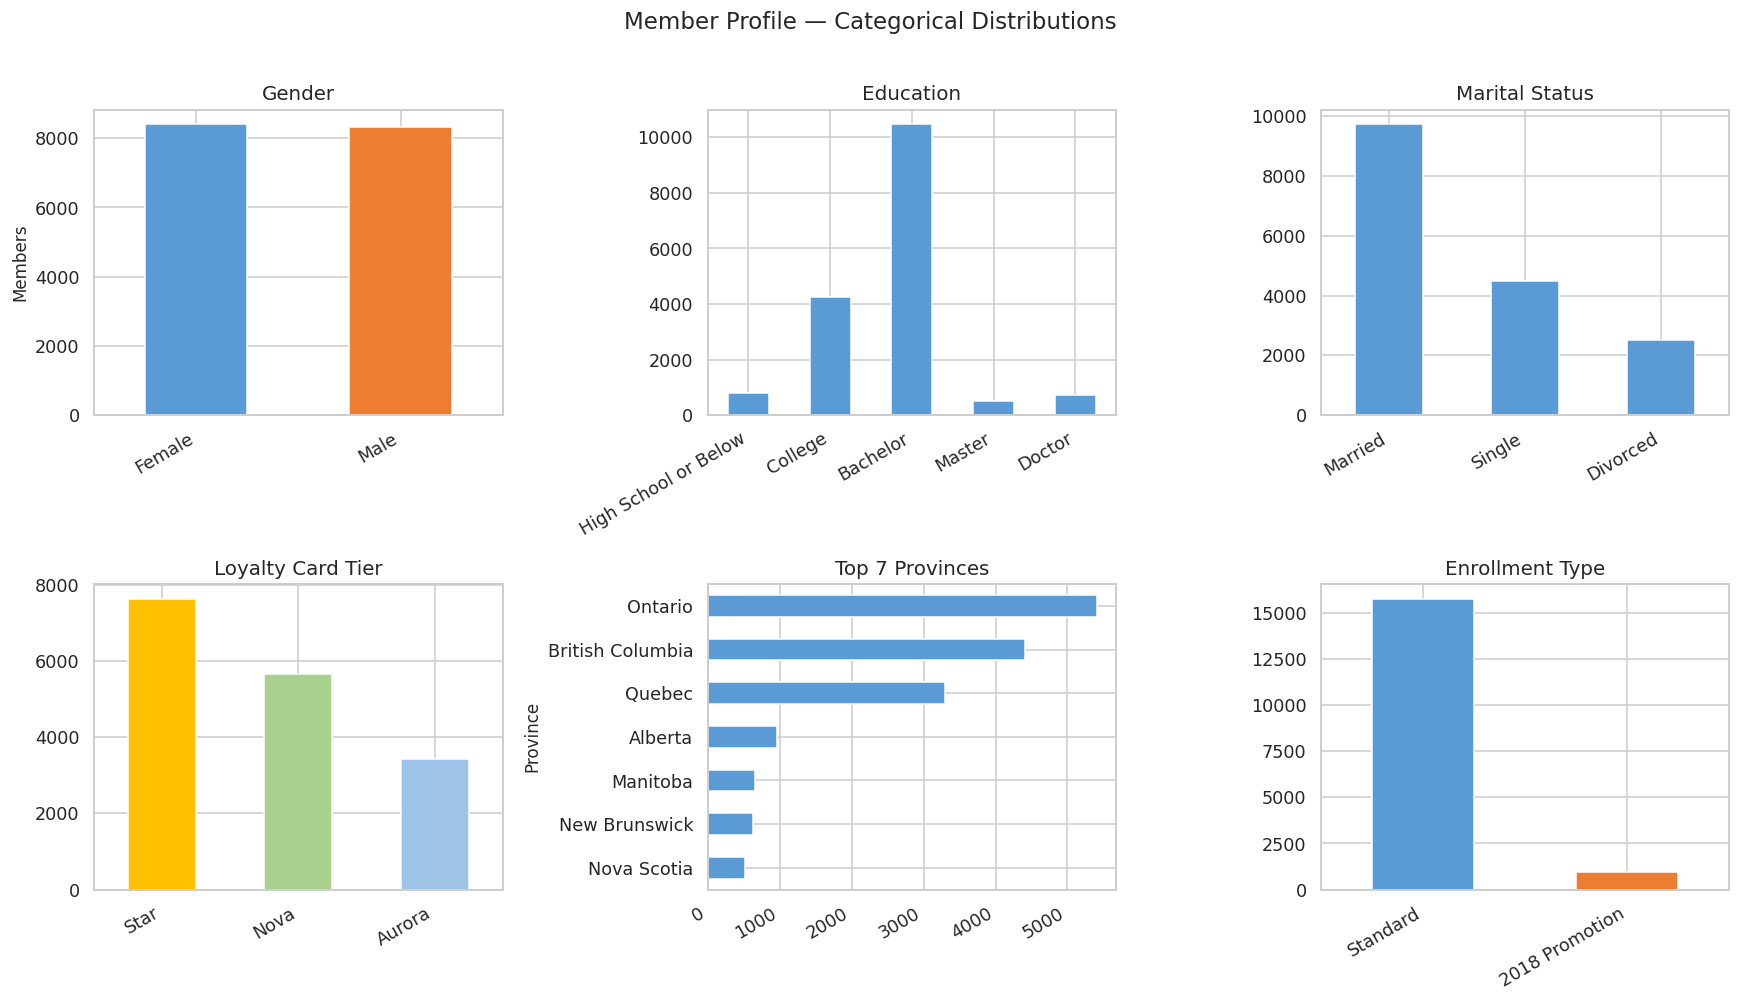

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Gender
loyalty['Gender'].value_counts().plot.bar(ax=axes[0,0], color=['#5B9BD5','#ED7D31'])
axes[0,0].set_title('Gender'); axes[0,0].set_ylabel('Members')

# Education
loyalty['Education'].value_counts().reindex(EDU_ORDER).plot.bar(ax=axes[0,1], color='#5B9BD5')
axes[0,1].set_title('Education')

# Marital Status
loyalty['Marital Status'].value_counts().plot.bar(ax=axes[0,2], color='#5B9BD5')
axes[0,2].set_title('Marital Status')

# Loyalty Card
loyalty['Loyalty Card'].value_counts().reindex(CARD_ORDER).plot.bar(ax=axes[1,0], color=['#FFC000','#A9D18E','#9DC3E6'])
axes[1,0].set_title('Loyalty Card Tier')

# Province (top 7)
loyalty['Province'].value_counts().head(7).plot.barh(ax=axes[1,1], color='#5B9BD5')
axes[1,1].set_title('Top 7 Provinces'); axes[1,1].invert_yaxis()

# Enrollment Type
loyalty['Enrollment Type'].value_counts().plot.bar(ax=axes[1,2], color=['#5B9BD5','#ED7D31'])
axes[1,2].set_title('Enrollment Type')

for ax in axes.flat:
    ax.set_xlabel('')
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(30)
        lbl.set_ha('right')
fig.suptitle('Member Profile — Categorical Distributions', fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

### 3.2  Salary distribution

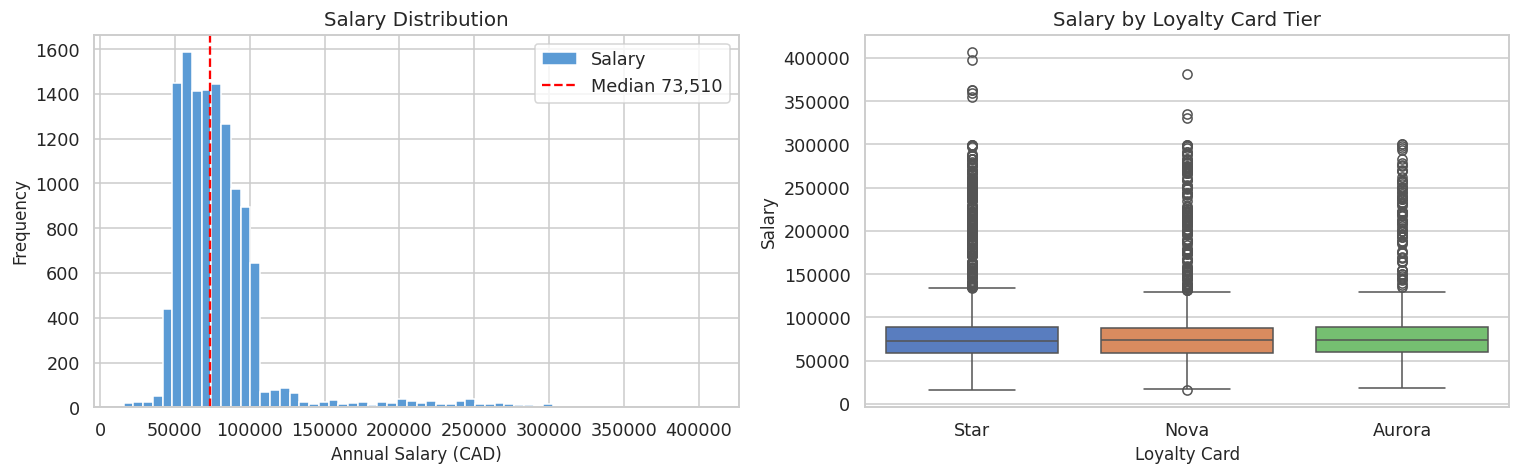

Salary — mean: 79,430  |  median: 73,510  |  std: 34,728


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

loyalty['Salary'].dropna().plot.hist(bins=60, ax=axes[0], color='#5B9BD5', edgecolor='white')
axes[0].set_title('Salary Distribution'); axes[0].set_xlabel('Annual Salary (CAD)')
axes[0].axvline(loyalty['Salary'].median(), color='red', ls='--', label=f"Median {loyalty['Salary'].median():,.0f}")
axes[0].legend()

sns.boxplot(data=loyalty, x='Loyalty Card', y='Salary', order=CARD_ORDER, ax=axes[1], palette='muted')
axes[1].set_title('Salary by Loyalty Card Tier')
fig.tight_layout()
plt.show()

print(f"Salary — mean: {loyalty['Salary'].mean():,.0f}  |  median: {loyalty['Salary'].median():,.0f}  |  std: {loyalty['Salary'].std():,.0f}")

### 3.3  Customer Lifetime Value (CLV)

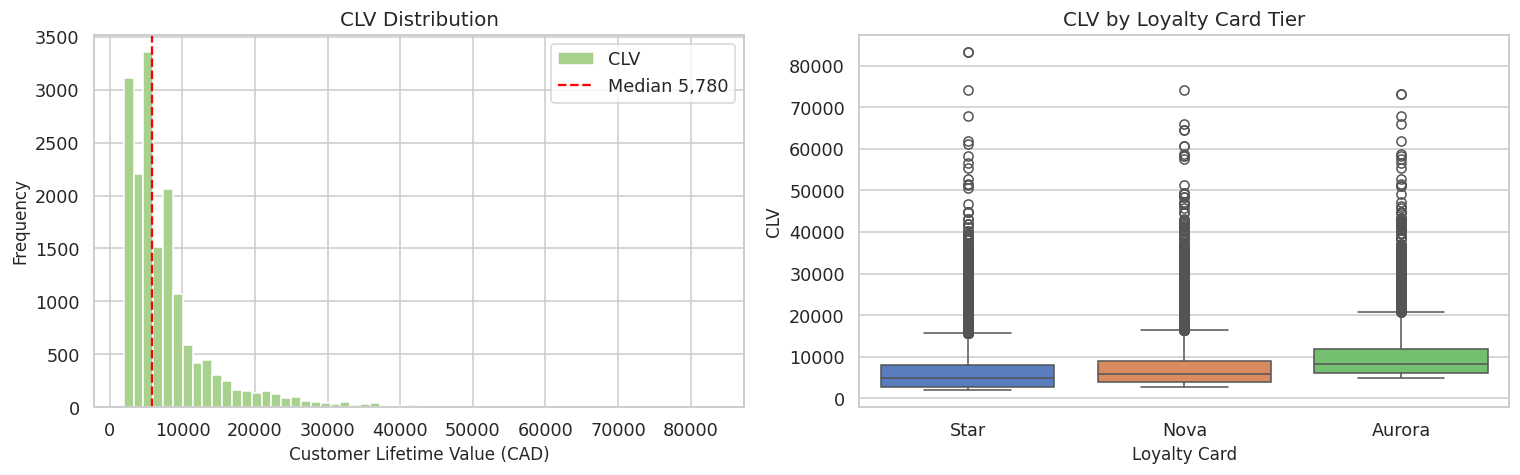

               count     mean     std     min     25%     50%      75%      max
Loyalty Card                                                                   
Star          7637.0   6741.8  6292.6  1898.0  2725.3  4786.9   7897.0  83325.4
Nova          5671.0   8045.6  6700.2  2738.0  4015.4  5799.1   8961.5  74228.5
Aurora        3429.0  10672.7  7528.9  4936.9  6063.2  8140.0  11895.2  73226.0


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

loyalty['CLV'].plot.hist(bins=60, ax=axes[0], color='#A9D18E', edgecolor='white')
axes[0].set_title('CLV Distribution'); axes[0].set_xlabel('Customer Lifetime Value (CAD)')
axes[0].axvline(loyalty['CLV'].median(), color='red', ls='--', label=f"Median {loyalty['CLV'].median():,.0f}")
axes[0].legend()

sns.boxplot(data=loyalty, x='Loyalty Card', y='CLV', order=CARD_ORDER, ax=axes[1], palette='muted')
axes[1].set_title('CLV by Loyalty Card Tier')
fig.tight_layout()
plt.show()

print(loyalty.groupby('Loyalty Card')['CLV'].describe().reindex(CARD_ORDER).round(1).to_string())

### 3.4  CLV vs Salary

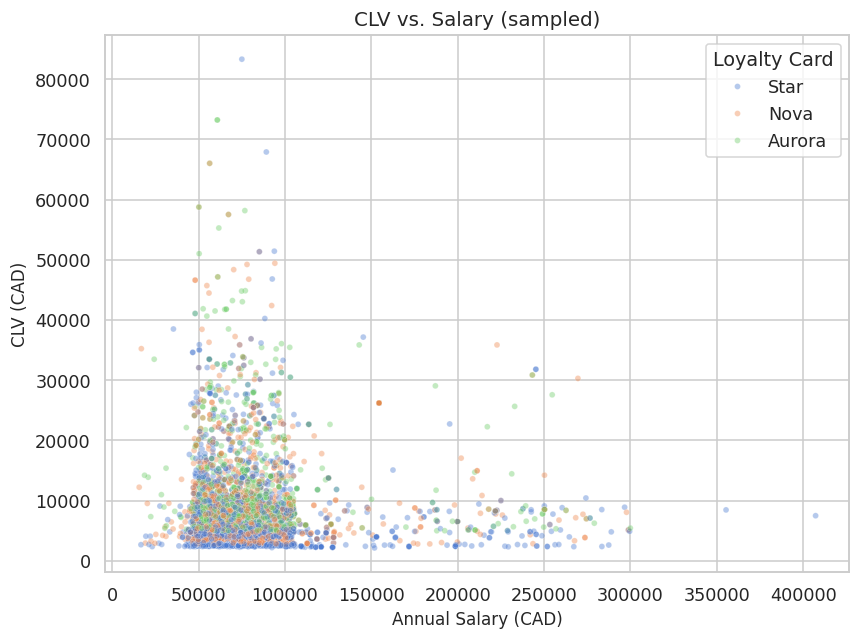

Pearson r = -0.021  (p = 0.0189)


In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = loyalty.dropna(subset=['Salary']).sample(min(5000, loyalty.dropna(subset=['Salary']).shape[0]), random_state=42)
sns.scatterplot(data=sample, x='Salary', y='CLV', hue='Loyalty Card', hue_order=CARD_ORDER,
                alpha=0.4, s=15, ax=ax)
ax.set_title('CLV vs. Salary (sampled)')
ax.set_xlabel('Annual Salary (CAD)'); ax.set_ylabel('CLV (CAD)')
plt.tight_layout(); plt.show()

r, p = stats.pearsonr(loyalty.dropna(subset=['Salary'])['Salary'], loyalty.dropna(subset=['Salary'])['CLV'])
print(f"Pearson r = {r:.3f}  (p = {p:.4f})")

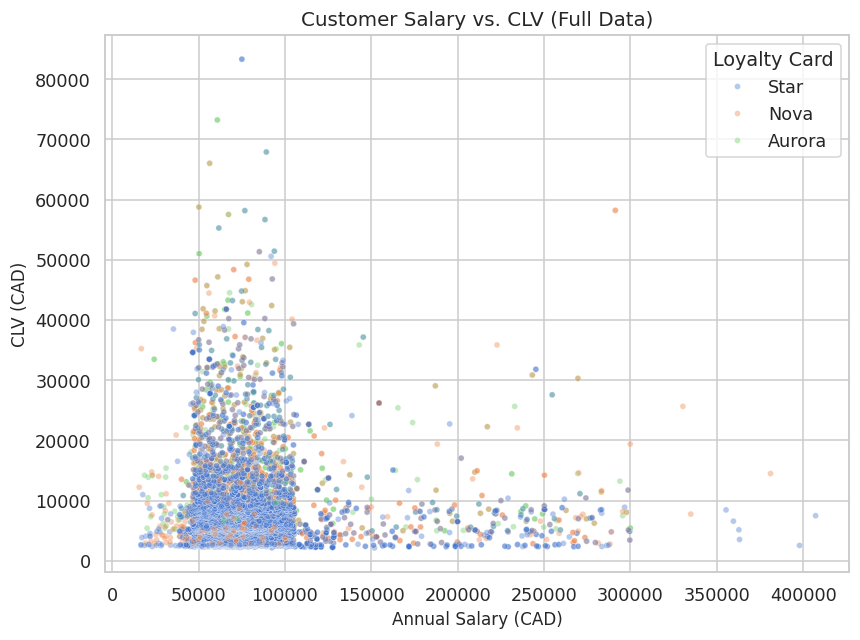

In [54]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=loyalty.dropna(subset=['Salary', 'CLV']), x='Salary', y='CLV', hue='Loyalty Card', hue_order=CARD_ORDER,
                alpha=0.4, s=15, ax=ax)
ax.set_title('Customer Salary vs. CLV (Full Data)')
ax.set_xlabel('Annual Salary (CAD)'); ax.set_ylabel('CLV (CAD)')
plt.tight_layout(); plt.show()

## 4 · Enrollment Timeline & Cancellations

### 4.1  Enrollments over time

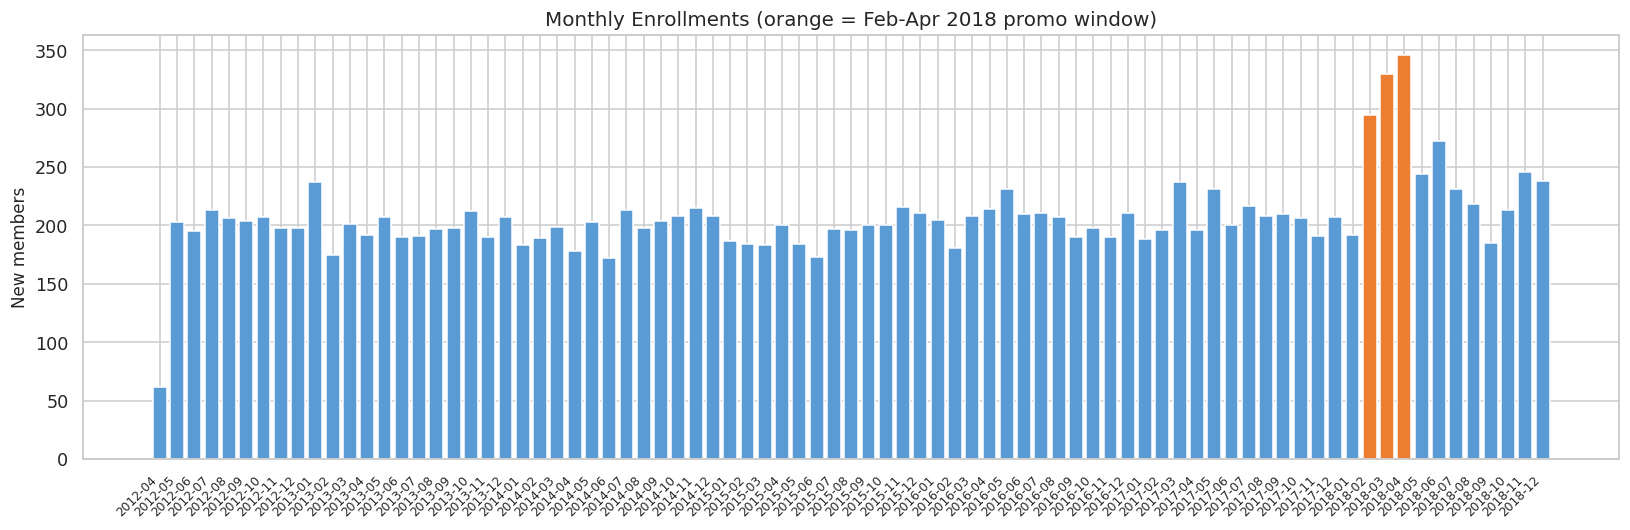

Total members enrolled via 2018 Promotion: 971
Total members enrolled Standard: 15766


In [55]:
enroll = loyalty.groupby(['Enrollment Year','Enrollment Month']).size().reset_index(name='Enrollments')
enroll['YM'] = enroll['Enrollment Year'].astype(str) + '-' + enroll['Enrollment Month'].apply(lambda m: f'{m:02d}')
enroll = enroll.sort_values('YM')

fig, ax = plt.subplots(figsize=(15, 5))
colors = ['#ED7D31' if (y == 2018 and m in [2,3,4]) else '#5B9BD5'
          for y, m in zip(enroll['Enrollment Year'], enroll['Enrollment Month'])]
ax.bar(range(len(enroll)), enroll['Enrollments'], color=colors, edgecolor='white')
ax.set_xticks(range(len(enroll)))
ax.set_xticklabels(enroll['YM'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Enrollments (orange = Feb-Apr 2018 promo window)')
ax.set_ylabel('New members')
plt.tight_layout(); plt.show()

print(f"Total members enrolled via 2018 Promotion: {(loyalty['Enrollment Type']=='2018 Promotion').sum()}")
print(f"Total members enrolled Standard: {(loyalty['Enrollment Type']=='Standard').sum()}")

### 4.2  Cancellation overview

Cancellation rate by enrollment type:
Enrollment Type
2018 Promotion    11.8
Standard          12.4


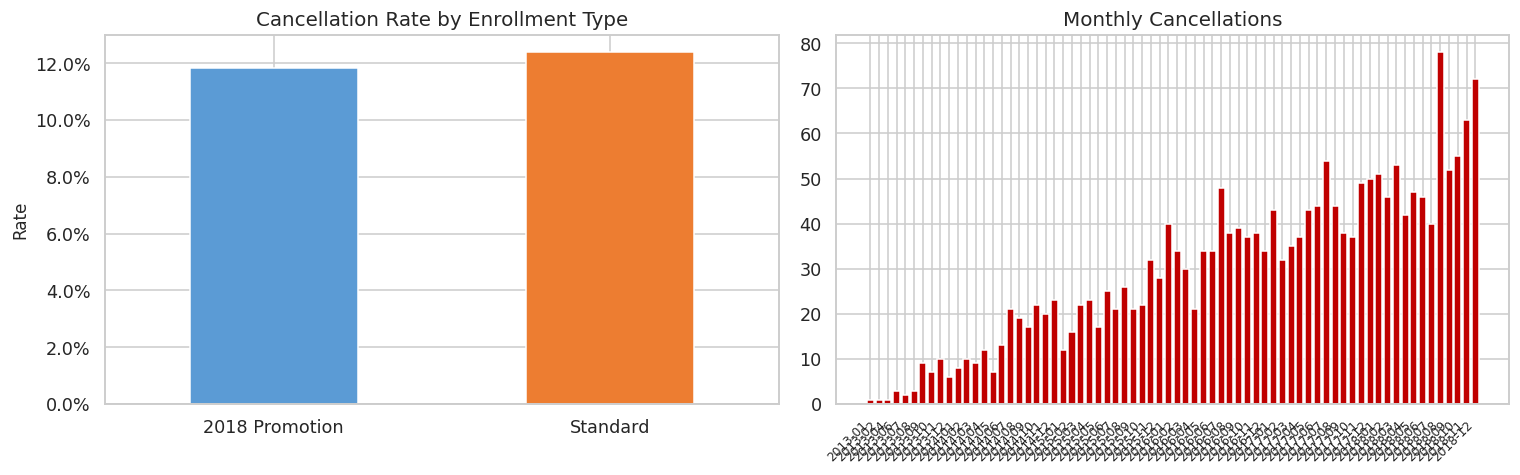

In [56]:
loyalty['is_cancelled'] = loyalty['Cancellation Year'].notna()

cancel_rate = loyalty.groupby('Enrollment Type')['is_cancelled'].mean()
print("Cancellation rate by enrollment type:")
print((cancel_rate * 100).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Cancellation rate by enrollment type
cancel_rate.plot.bar(ax=axes[0], color=['#5B9BD5','#ED7D31'])
axes[0].set_title('Cancellation Rate by Enrollment Type')
axes[0].set_ylabel('Rate'); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_xlabel(''); axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Cancellations over time
cancelled = loyalty[loyalty['is_cancelled']].copy()
cancel_ts = cancelled.groupby(['Cancellation Year','Cancellation Month']).size().reset_index(name='Cancellations')
cancel_ts['YM'] = cancel_ts['Cancellation Year'].astype(int).astype(str) + '-' + cancel_ts['Cancellation Month'].astype(int).apply(lambda m: f'{m:02d}')
cancel_ts = cancel_ts.sort_values('YM')
axes[1].bar(range(len(cancel_ts)), cancel_ts['Cancellations'], color='#C00000', edgecolor='white')
axes[1].set_xticks(range(len(cancel_ts)))
axes[1].set_xticklabels(cancel_ts['YM'], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Monthly Cancellations')

fig.tight_layout(); plt.show()

In [57]:
loyalty_filtered = loyalty[
    (loyalty['Enrollment Year'] == 2018) &
    (loyalty['Enrollment Month'] >= 2) &
    (loyalty['Enrollment Month'] <= 4) &
    (loyalty['Enrollment Type'] == 'Standard')
].copy()

loyalty_filtered['is_cancelled'] = loyalty_filtered['Cancellation Year'].notna()

# Calculate cancellation rate by enrollment type for the filtered data
cancel_rate_feb_2018_enrollments = loyalty_filtered.groupby('Enrollment Type')['is_cancelled'].mean()

# Calculate the count of new members for each enrollment type
member_counts_feb_2018_enrollments = loyalty_filtered.groupby('Enrollment Type').size()

print("Cancellation rate by enrollment type (Feb-Apr 2018 Standard enrollments only):")
print((cancel_rate_feb_2018_enrollments * 100).round(1).to_string())
print("\nMember counts by enrollment type (Feb-Apr 2018 Standard enrollments only):")
print(member_counts_feb_2018_enrollments.to_string())

if not loyalty_filtered.empty:
    # Visualize the cancellation rates and member counts on a dual-axis chart
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Plot cancellation rates on the first y-axis
    cancel_rate_feb_2018_enrollments.plot.bar(ax=ax1, color=['#5B9BD5'], position=1, width=0.4, label='Cancellation Rate')
    ax1.set_title('Cancellation Rate and Member Count for Standard Enrollments (Feb-Apr 2018 Only)')
    ax1.set_ylabel('Cancellation Rate')
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax1.set_xlabel('')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

    # Create a second y-axis for member counts
    ax2 = ax1.twinx()
    member_counts_feb_2018_enrollments.plot.bar(ax=ax2, color=['#A9D18E'], position=0, width=0.4, label='Member Count')
    ax2.set_ylabel('Number of Members')

    # Adjust x-tick labels to be centered between the two bars for each group
    ax1.set_xticks(range(len(cancel_rate_feb_2018_enrollments)))
    ax1.set_xticklabels(cancel_rate_feb_2018_enrollments.index)

    # Combine legends
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("\nNo 'Standard' enrollments found for Feb-Apr 2018 to plot.")

Cancellation rate by enrollment type (Feb-Apr 2018 Standard enrollments only):
Series([], )

Member counts by enrollment type (Feb-Apr 2018 Standard enrollments only):
Series([], )

No 'Standard' enrollments found for Feb-Apr 2018 to plot.


צריך להבין מה הבייסליין - האם ה-11 אחוז ביטולים של הפרומושן 2018 זה "טוב" ביחס לבייסליין.
זאת שאלה איך לבדוק את הבייסליין - אולי צריך להוציא החוצה את פבראור-אפריל 2018.

Cancellation Rates:
                              Cancellation Rate
Cohort                                         
2018 Promotion (Feb-Dec)                   11.8
Baseline (2013-2017 Feb-Dec)               15.7


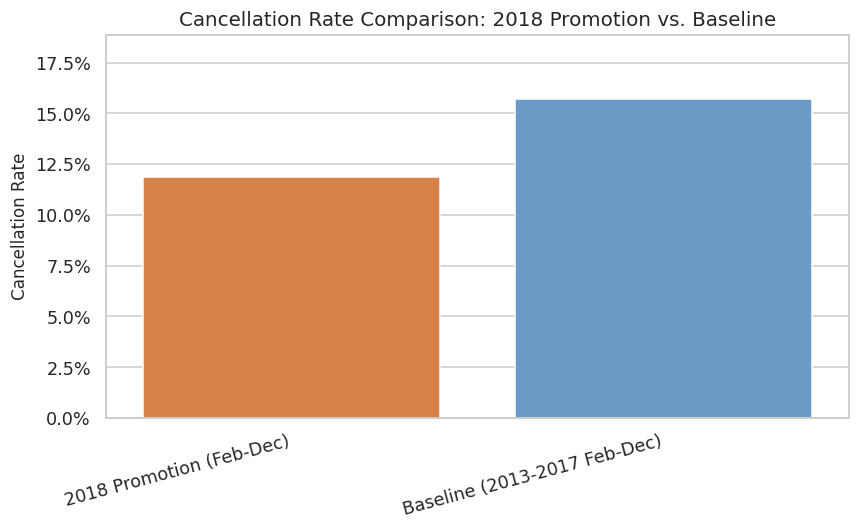

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Define the promo cohort (2018 Promotion, months 2-12)
promo_cohort = loyalty[
    (loyalty['Enrollment Type'] == '2018 Promotion') &
    (loyalty['Enrollment Year'] == 2018) &
    (loyalty['Enrollment Month'] >= 2) &
    (loyalty['Enrollment Month'] <= 12)
].copy()

# Define the baseline cohort (Standard enrollments, 2013-2017, months 2-12)
baseline_cohort = loyalty[
    (loyalty['Enrollment Type'] == 'Standard') &
    (loyalty['Enrollment Year'] >= 2013) &
    (loyalty['Enrollment Year'] <= 2017) &
    (loyalty['Enrollment Month'] >= 2) &
    (loyalty['Enrollment Month'] <= 12)
].copy()

# Ensure the 'is_cancelled' column is available for both cohorts
promo_cohort['is_cancelled'] = promo_cohort['Cancellation Year'].notna()
baseline_cohort['is_cancelled'] = baseline_cohort['Cancellation Year'].notna()

# Calculate cancellation rates
promo_cancel_rate = promo_cohort['is_cancelled'].mean()
baseline_cancel_rate = baseline_cohort['is_cancelled'].mean()

cancellation_rates = pd.DataFrame({
    'Cohort': ['2018 Promotion (Feb-Dec)', 'Baseline (2013-2017 Feb-Dec)'],
    'Cancellation Rate': [promo_cancel_rate, baseline_cancel_rate]
})

print("Cancellation Rates:")
print((cancellation_rates.set_index('Cohort') * 100).round(1).to_string())

# Plotting the cancellation rates
plt.figure(figsize=(8, 5))
sns.barplot(x='Cohort', y='Cancellation Rate', data=cancellation_rates, palette=['#ED7D31', '#5B9BD5'])
plt.title('Cancellation Rate Comparison: 2018 Promotion vs. Baseline')
plt.ylabel('Cancellation Rate')
plt.ylim(0, cancellation_rates['Cancellation Rate'].max() * 1.2)
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xlabel('')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 4.3  Net membership growth

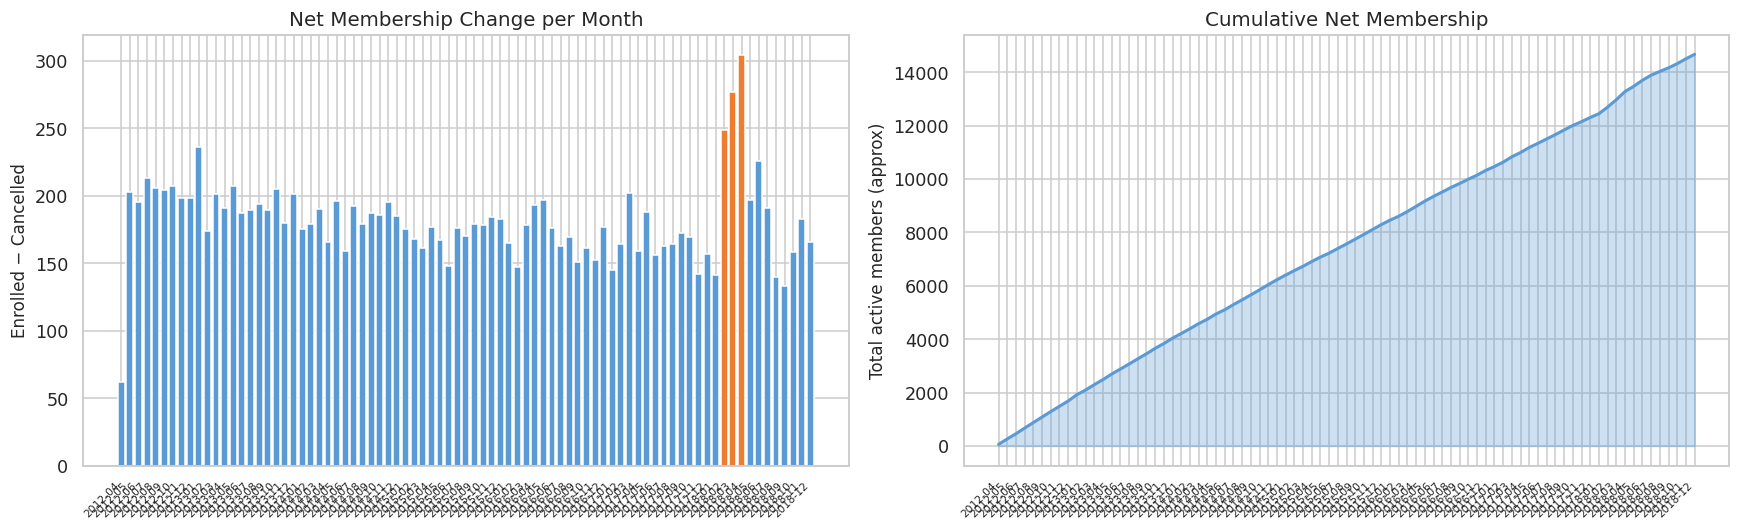

Promo window (Feb-Apr 2018): Gross enrollments = 971, Cancellations = 141, Net = 830


In [22]:
# Build monthly series: enrollments - cancellations
all_months = sorted(enroll['YM'].tolist())

cancel_by_ym = cancel_ts.set_index('YM')['Cancellations'].to_dict()
enroll_by_ym = enroll.set_index('YM')['Enrollments'].to_dict()

net_df = pd.DataFrame({'YM': all_months})
net_df['Enrolled'] = net_df['YM'].map(enroll_by_ym).fillna(0).astype(int)
net_df['Cancelled'] = net_df['YM'].map(cancel_by_ym).fillna(0).astype(int)
net_df['Net'] = net_df['Enrolled'] - net_df['Cancelled']
net_df['Cumulative'] = net_df['Net'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Net monthly
c = ['#ED7D31' if ym in ['2018-02','2018-03','2018-04'] else '#5B9BD5' for ym in net_df['YM']]
axes[0].bar(range(len(net_df)), net_df['Net'], color=c, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xticks(range(len(net_df)))
axes[0].set_xticklabels(net_df['YM'], rotation=45, ha='right', fontsize=7)
axes[0].set_title('Net Membership Change per Month')
axes[0].set_ylabel('Enrolled − Cancelled')

# Cumulative
axes[1].fill_between(range(len(net_df)), net_df['Cumulative'], alpha=0.3, color='#5B9BD5')
axes[1].plot(range(len(net_df)), net_df['Cumulative'], color='#5B9BD5', lw=2)
axes[1].set_xticks(range(len(net_df)))
axes[1].set_xticklabels(net_df['YM'], rotation=45, ha='right', fontsize=7)
axes[1].set_title('Cumulative Net Membership')
axes[1].set_ylabel('Total active members (approx)')

fig.tight_layout(); plt.show()

promo_gross = net_df[net_df['YM'].isin(['2018-02','2018-03','2018-04'])]['Enrolled'].sum()
promo_cancel = net_df[net_df['YM'].isin(['2018-02','2018-03','2018-04'])]['Cancelled'].sum()
print(f"Promo window (Feb-Apr 2018): Gross enrollments = {promo_gross}, Cancellations = {promo_cancel}, Net = {promo_gross - promo_cancel}")

## 5 · Campaign Demographic Adoption

> *"Was the campaign adoption more successful for certain demographics?"*

We compare the **2018 Promotion** cohort against **Standard** enrollees across gender, education, marital status, loyalty card tier, salary, and province.

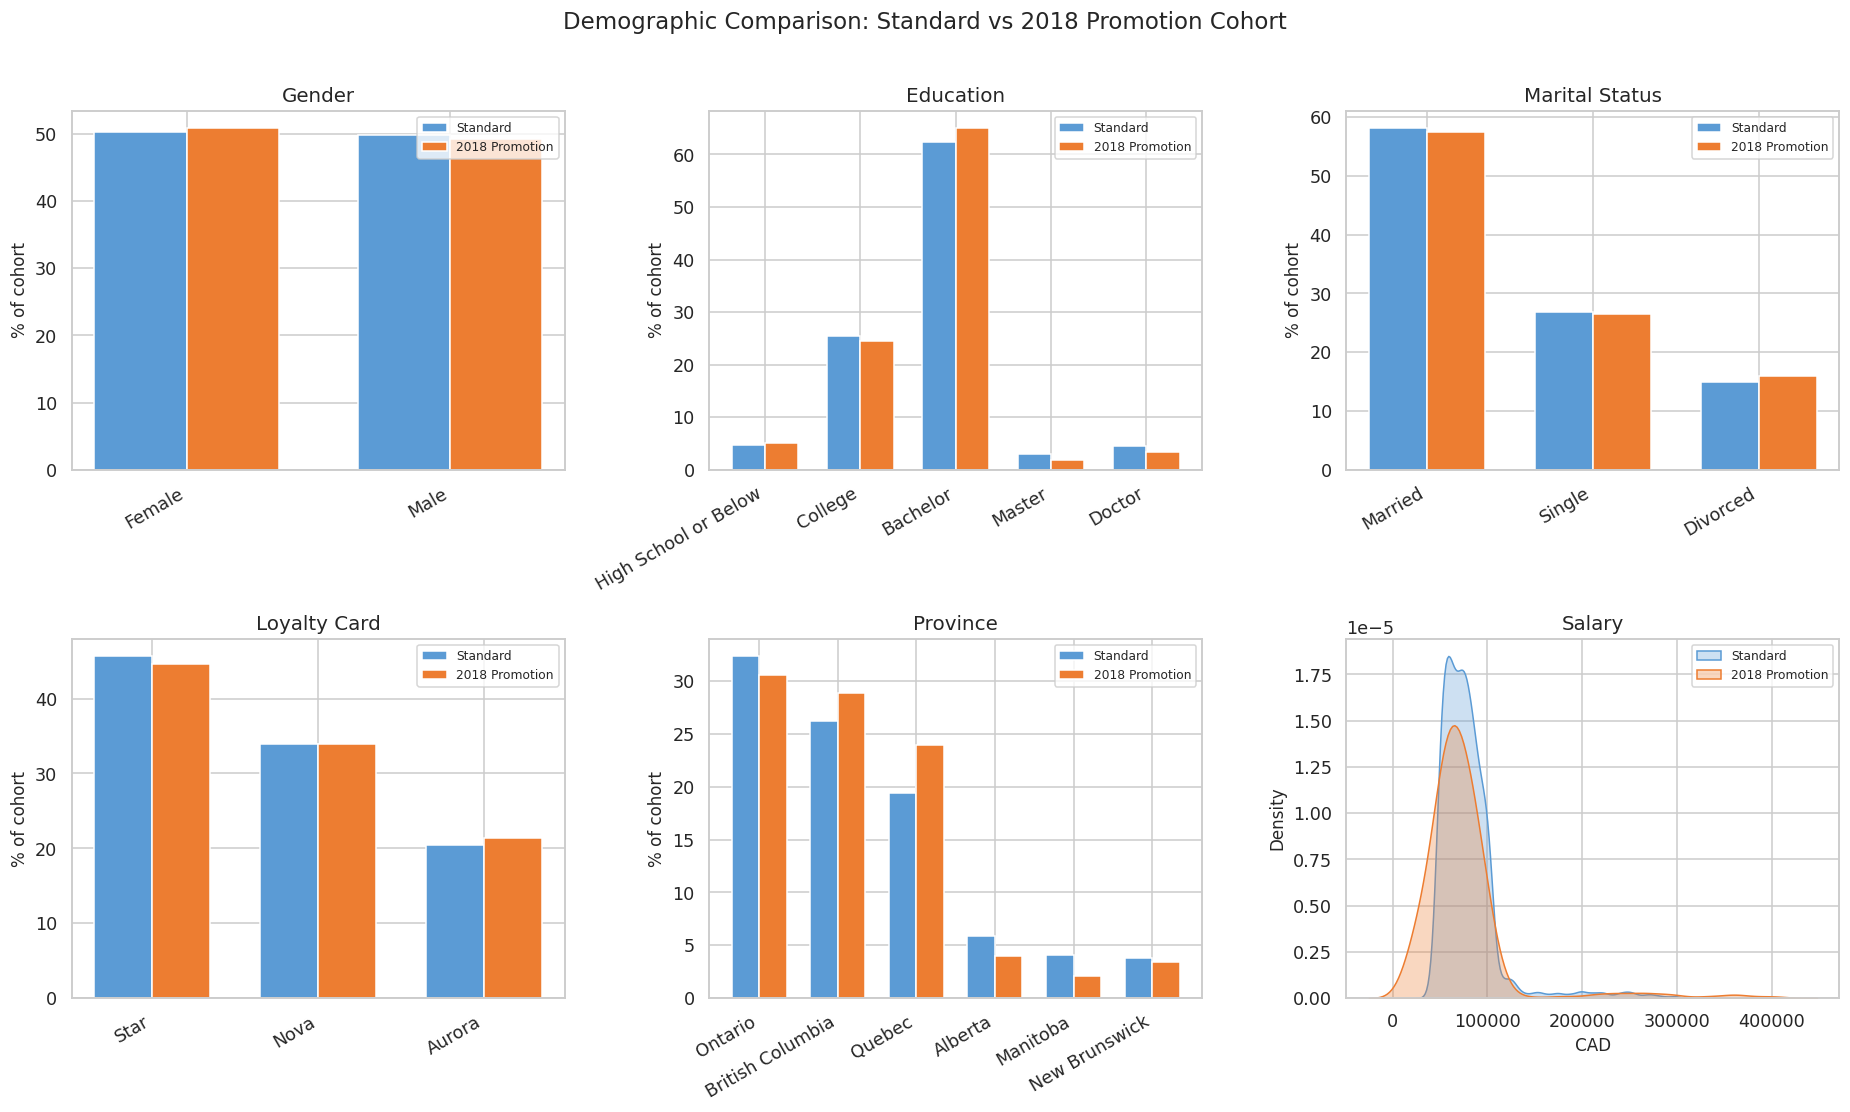

In [23]:
promo = loyalty[loyalty['Enrollment Type'] == '2018 Promotion']
standard = loyalty[loyalty['Enrollment Type'] == 'Standard']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# helper: grouped bar comparison (pct within each cohort)
def compare_bar(ax, col, order=None):
    p_pct = promo[col].value_counts(normalize=True).reindex(order) * 100
    s_pct = standard[col].value_counts(normalize=True).reindex(order) * 100
    x = np.arange(len(p_pct))
    w = 0.35
    ax.bar(x - w/2, s_pct, w, label='Standard', color='#5B9BD5')
    ax.bar(x + w/2, p_pct, w, label='2018 Promotion', color='#ED7D31')
    ax.set_xticks(x)
    ax.set_xticklabels(p_pct.index, rotation=30, ha='right')
    ax.set_title(col); ax.set_ylabel('% of cohort')
    ax.legend(fontsize=8)

compare_bar(axes[0,0], 'Gender')
compare_bar(axes[0,1], 'Education', EDU_ORDER)
compare_bar(axes[0,2], 'Marital Status')
compare_bar(axes[1,0], 'Loyalty Card', CARD_ORDER)
compare_bar(axes[1,1], 'Province', loyalty['Province'].value_counts().head(6).index.tolist())

# Salary comparison
sns.kdeplot(standard['Salary'].dropna(), ax=axes[1,2], label='Standard', color='#5B9BD5', fill=True, alpha=.3)
sns.kdeplot(promo['Salary'].dropna(), ax=axes[1,2], label='2018 Promotion', color='#ED7D31', fill=True, alpha=.3)
axes[1,2].set_title('Salary'); axes[1,2].set_xlabel('CAD'); axes[1,2].legend(fontsize=8)

fig.suptitle('Demographic Comparison: Standard vs 2018 Promotion Cohort', fontsize=15, y=1.01)
fig.tight_layout(); plt.show()

In [24]:
# Statistical test: is the promotion cohort's demographic mix significantly different?
# Chi-squared tests for categorical variables
for col in ['Gender','Education','Marital Status','Loyalty Card']:
    ct = pd.crosstab(loyalty['Enrollment Type'], loyalty[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"{col:20s}  χ² = {chi2:8.1f}  p = {p:.4f} {sig}")

# Salary: Mann-Whitney
u, p = stats.mannwhitneyu(standard['Salary'].dropna(), promo['Salary'].dropna(), alternative='two-sided')
print(f"{'Salary (MW-U)':20s}  U = {u:.0f}  p = {p:.4f} {'***' if p<0.001 else ''}")

print("\nMean salary — Standard:", f"{standard['Salary'].mean():,.0f}",
      " | Promo:", f"{promo['Salary'].mean():,.0f}")

Gender                χ² =      0.1  p = 0.7115 
Education             χ² =      8.5  p = 0.0736 
Marital Status        χ² =      0.7  p = 0.7107 
Loyalty Card          χ² =      0.7  p = 0.7102 
Salary (MW-U)         U = 5026322  p = 0.0000 ***

Mean salary — Standard: 79,717  | Promo: 74,684


## 6 · Flight Activity — General EDA

### 6.1  Monthly totals (2017 vs 2018)

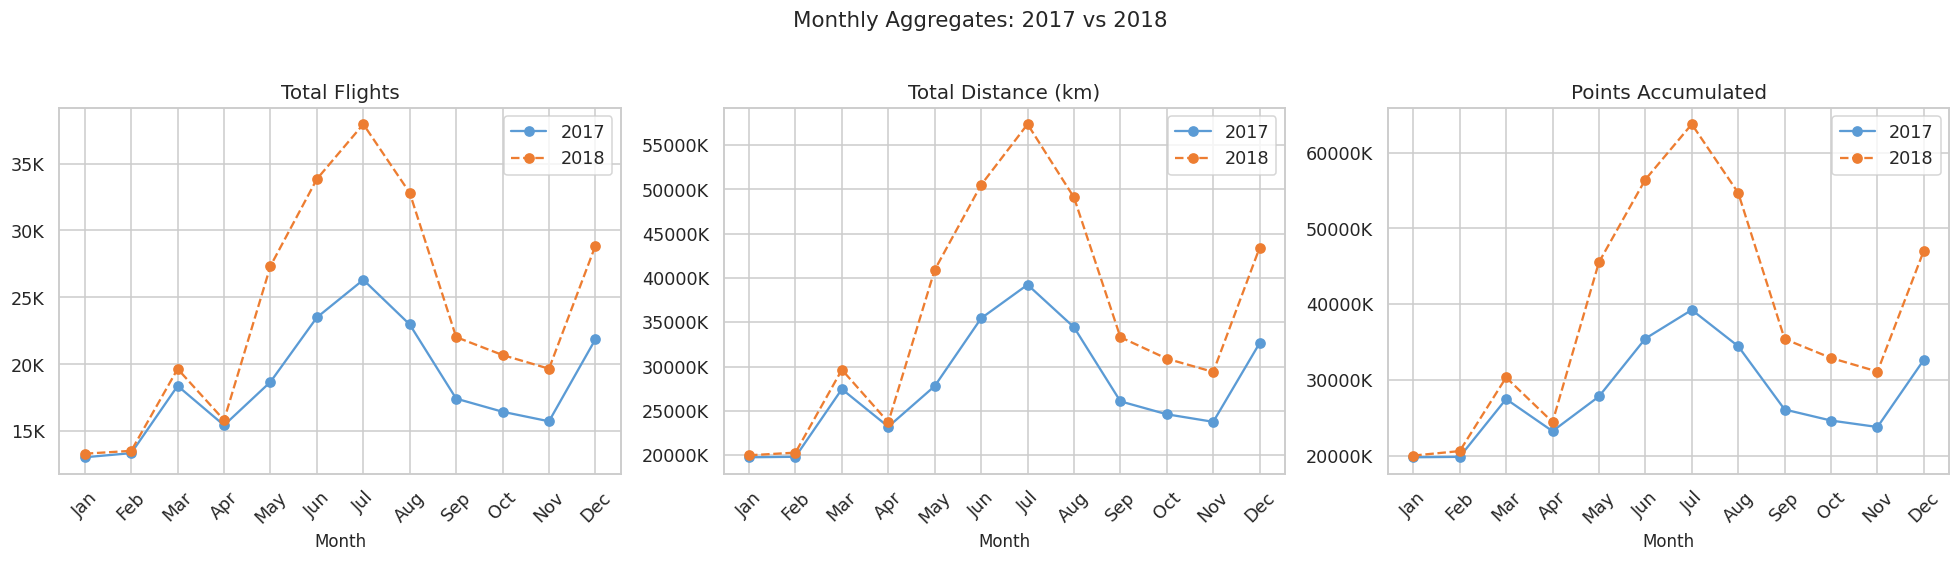

In [25]:
monthly = flights.groupby(['Year','Month']).agg(
    total_flights=('Total Flights','sum'),
    mean_flights=('Total Flights','mean'),
    total_distance=('Distance','sum'),
    total_pts_acc=('Points Accumulated','sum'),
    total_pts_red=('Points Redeemed','sum'),
    members=('Loyalty Number','nunique')
).reset_index()
monthly['Month_name'] = monthly['Month'].map(MONTH_NAMES)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (metric, label) in enumerate([('total_flights','Total Flights'),
                                      ('total_distance','Total Distance (km)'),
                                      ('total_pts_acc','Points Accumulated')]):
    for yr, c, ls in [(2017,'#5B9BD5','-'),(2018,'#ED7D31','--')]:
        sub = monthly[monthly['Year']==yr]
        axes[i].plot(sub['Month'], sub[metric], marker='o', color=c, ls=ls, label=str(yr))
    axes[i].set_title(label); axes[i].set_xlabel('Month')
    axes[i].set_xticks(range(1,13)); axes[i].set_xticklabels([MONTH_NAMES[m] for m in range(1,13)], rotation=45)
    axes[i].legend()
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.suptitle('Monthly Aggregates: 2017 vs 2018', fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

 6.2  Per-member monthly distributions

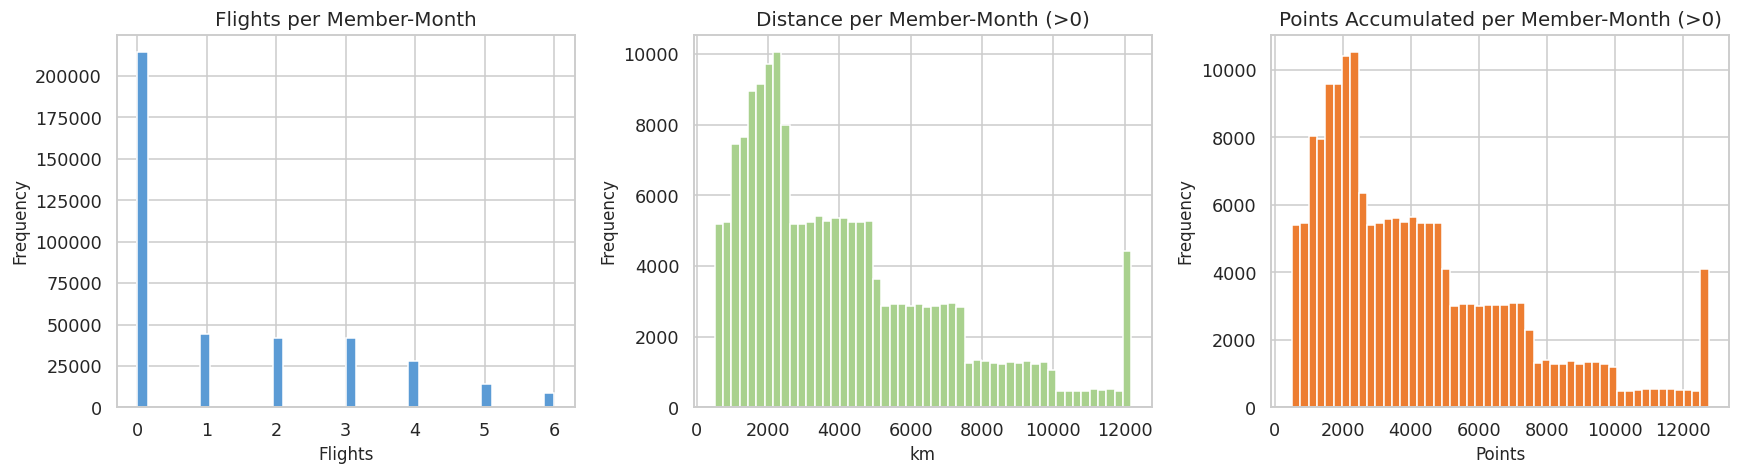

54.5% of member-months have zero flights


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

flights['Total Flights'].clip(upper=flights['Total Flights'].quantile(0.99)).plot.hist(
    bins=40, ax=axes[0], color='#5B9BD5', edgecolor='white')
axes[0].set_title('Flights per Member-Month'); axes[0].set_xlabel('Flights')

flights[flights['Distance']>0]['Distance'].clip(upper=flights['Distance'].quantile(0.99)).plot.hist(
    bins=50, ax=axes[1], color='#A9D18E', edgecolor='white')
axes[1].set_title('Distance per Member-Month (>0)'); axes[1].set_xlabel('km')

flights[flights['Points Accumulated']>0]['Points Accumulated'].clip(
    upper=flights['Points Accumulated'].quantile(0.99)).plot.hist(
    bins=50, ax=axes[2], color='#ED7D31', edgecolor='white')
axes[2].set_title('Points Accumulated per Member-Month (>0)'); axes[2].set_xlabel('Points')

fig.tight_layout(); plt.show()

# Zero-flight months
zero_pct = (flights['Total Flights']==0).mean()*100
print(f"{zero_pct:.1f}% of member-months have zero flights")

### 6.3  Points economy: accumulation vs. redemption

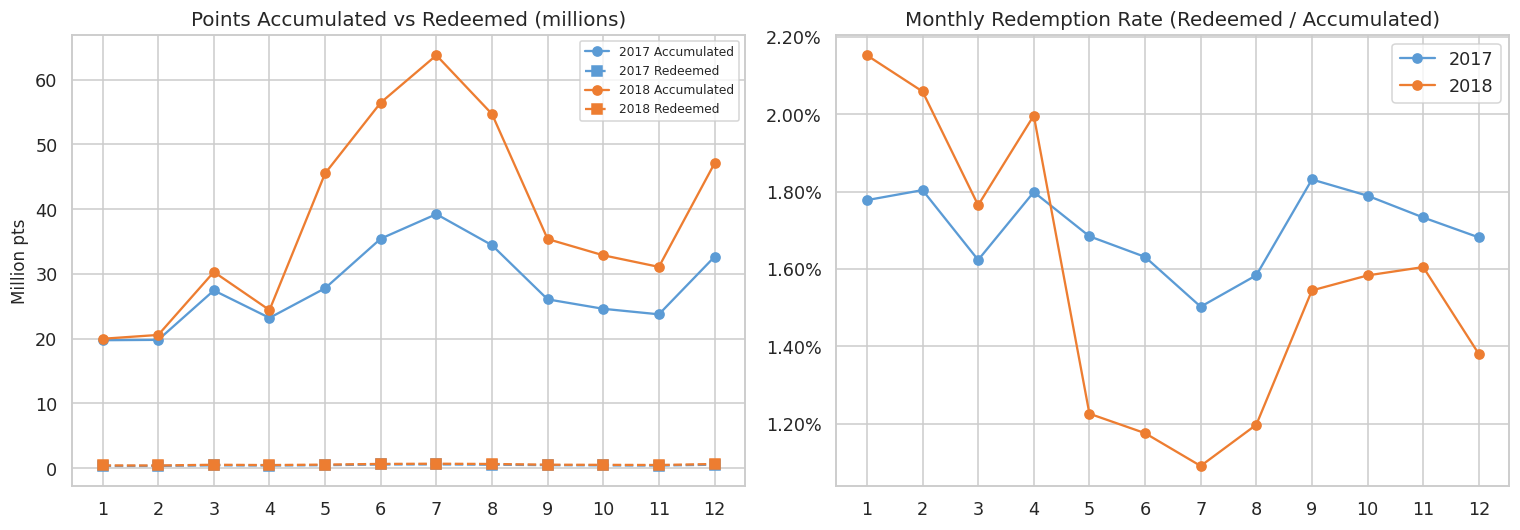

In [27]:
pts = flights.groupby(['Year','Month']).agg(
    accumulated=('Points Accumulated','sum'),
    redeemed=('Points Redeemed','sum'),
    dollar_redeemed=('Dollar Cost Points Redeemed','sum')
).reset_index()
pts['redemption_rate'] = pts['redeemed'] / pts['accumulated']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for yr, c in [(2017,'#5B9BD5'),(2018,'#ED7D31')]:
    sub = pts[pts['Year']==yr]
    axes[0].plot(sub['Month'], sub['accumulated']/1e6, marker='o', color=c, label=f'{yr} Accumulated')
    axes[0].plot(sub['Month'], sub['redeemed']/1e6, marker='s', ls='--', color=c, label=f'{yr} Redeemed')
axes[0].set_title('Points Accumulated vs Redeemed (millions)'); axes[0].set_ylabel('Million pts')
axes[0].set_xticks(range(1,13)); axes[0].legend(fontsize=8)

for yr, c in [(2017,'#5B9BD5'),(2018,'#ED7D31')]:
    sub = pts[pts['Year']==yr]
    axes[1].plot(sub['Month'], sub['redemption_rate'], marker='o', color=c, label=str(yr))
axes[1].set_title('Monthly Redemption Rate (Redeemed / Accumulated)')
axes[1].set_xticks(range(1,13)); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend()

fig.tight_layout(); plt.show()

## 7 · Campaign Impact on Summer Flights

> *"What impact did the campaign have on booked flights during summer?"*

We merge loyalty history with flight activity and compare **Promotion vs Standard** cohorts, plus **2017 vs 2018** overall summers.

In [28]:
merged = flights.merge(loyalty[['Loyalty Number','Enrollment Type','Enrollment Year',
                                  'Enrollment Month','Loyalty Card','Gender',
                                  'Education','Marital Status','CLV','Salary']],
                       on='Loyalty Number', how='left')

summer = merged[(merged['Month'].isin([6,7,8]))]
summer_2018 = summer[summer['Year']==2018]
summer_2017 = summer[summer['Year']==2017]

print("=== Summer (Jun-Aug) Flights Summary ===")
for label, df in [('Summer 2017', summer_2017), ('Summer 2018', summer_2018)]:
    print(f"\n{label}: {df['Total Flights'].sum():,} flights | "
          f"{df['Loyalty Number'].nunique():,} members | "
          f"mean {df['Total Flights'].mean():.2f} flights/member-month")


=== Summer (Jun-Aug) Flights Summary ===

Summer 2017: 72,792 flights | 15,766 members | mean 1.52 flights/member-month

Summer 2018: 104,584 flights | 16,737 members | mean 2.06 flights/member-month


In [29]:
# Breakdown: promo vs standard in summer 2018
summer_comp = summer_2018.groupby('Enrollment Type').agg(
    member_months=('Total Flights','count'),
    total_flights=('Total Flights','sum'),
    mean_flights=('Total Flights','mean'),
    total_distance=('Distance','sum'),
    mean_distance=('Distance','mean'),
    unique_members=('Loyalty Number','nunique')
).round(2)

print(summer_comp.to_string())
print(f"\nPromo members flew on avg {summer_comp.loc['2018 Promotion','mean_flights']:.1f} "
      f"flights/month vs {summer_comp.loc['Standard','mean_flights']:.1f} for Standard members.")

                 member_months  total_flights  mean_flights  total_distance  mean_distance  unique_members
Enrollment Type                                                                                           
2018 Promotion            2928          24040          8.21        35978708       12287.81             971
Standard                 47775          80544          1.69       120964427        2531.96           15766

Promo members flew on avg 8.2 flights/month vs 1.7 for Standard members.


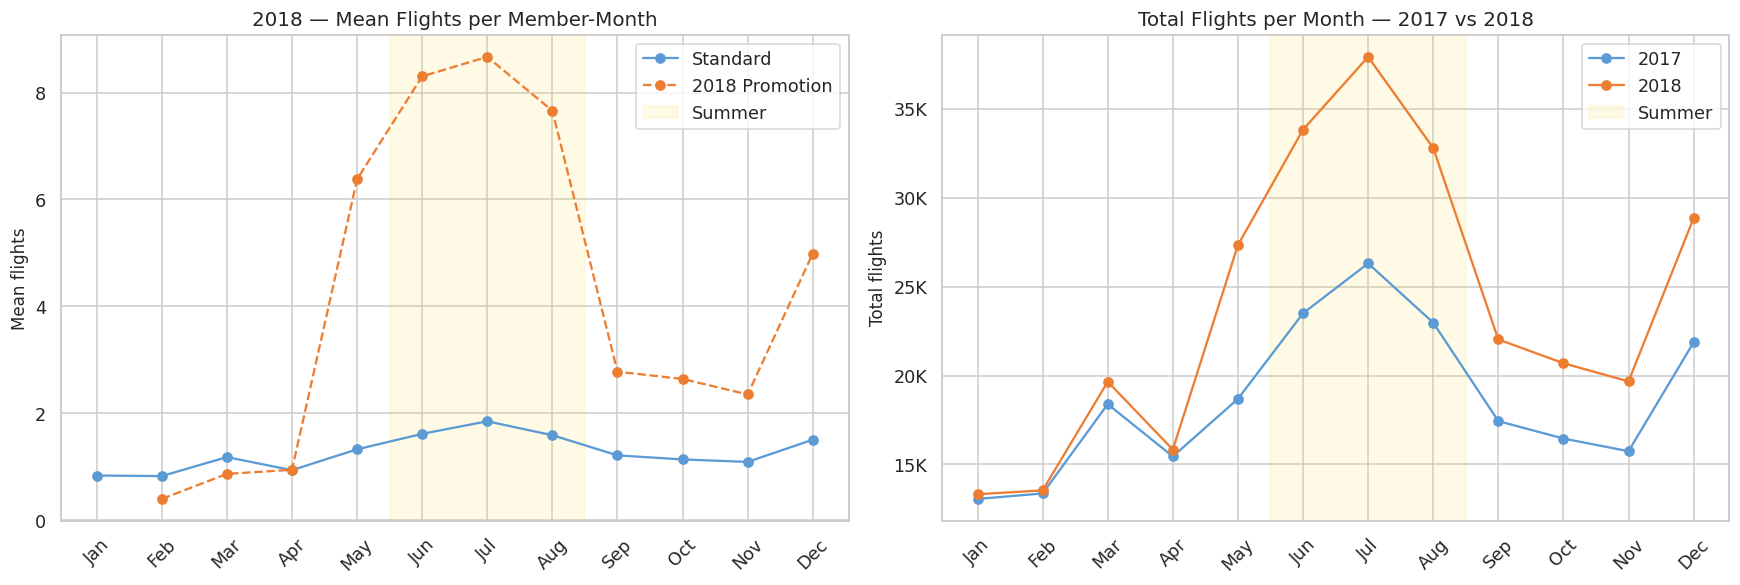

In [30]:
# Monthly comparison by cohort
cohort_monthly = merged.groupby(['Year','Month','Enrollment Type']).agg(
    mean_flights=('Total Flights','mean'),
    total_flights=('Total Flights','sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 2018 only: mean flights per month, promo vs standard
for etype, c, ls in [('Standard','#5B9BD5','-'),('2018 Promotion','#ED7D31','--')]:
    sub = cohort_monthly[(cohort_monthly['Year']==2018) & (cohort_monthly['Enrollment Type']==etype)]
    axes[0].plot(sub['Month'], sub['mean_flights'], marker='o', color=c, ls=ls, label=etype)

axes[0].axvspan(5.5, 8.5, alpha=0.1, color='gold', label='Summer')
axes[0].set_title('2018 — Mean Flights per Member-Month')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels([MONTH_NAMES[m] for m in range(1,13)], rotation=45)
axes[0].legend(); axes[0].set_ylabel('Mean flights')

# 2017 vs 2018 total flights
for yr, c in [(2017,'#5B9BD5'),(2018,'#ED7D31')]:
    sub = cohort_monthly[cohort_monthly['Year']==yr].groupby('Month')['total_flights'].sum()
    axes[1].plot(sub.index, sub.values, marker='o', color=c, label=str(yr))

axes[1].axvspan(5.5, 8.5, alpha=0.1, color='gold', label='Summer')
axes[1].set_title('Total Flights per Month — 2017 vs 2018')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels([MONTH_NAMES[m] for m in range(1,13)], rotation=45)
axes[1].legend(); axes[1].set_ylabel('Total flights')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.tight_layout(); plt.show()

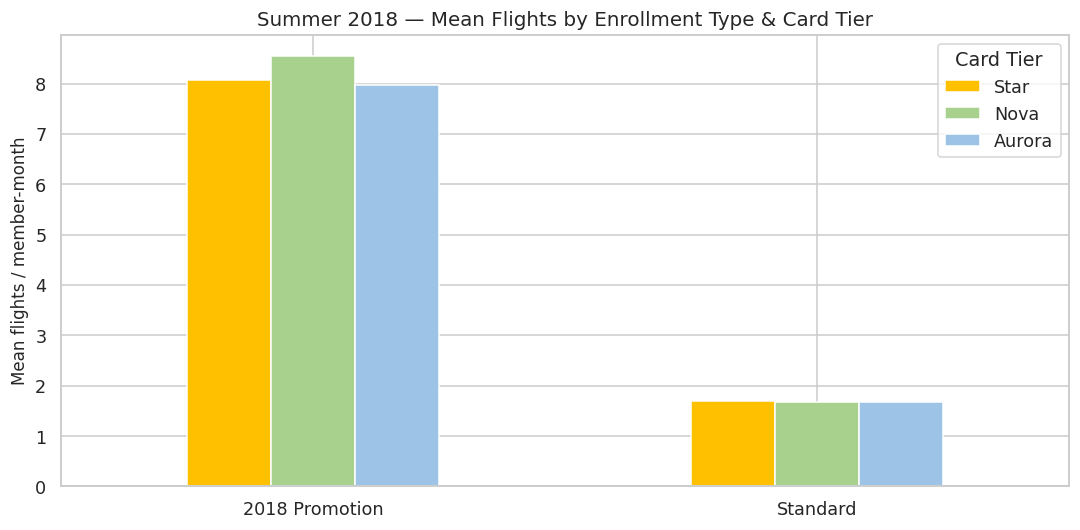

In [31]:
# Flight activity by loyalty card tier for promo cohort
fig, ax = plt.subplots(figsize=(10, 5))
tier_summer = summer_2018.groupby(['Enrollment Type','Loyalty Card'])['Total Flights'].mean().unstack('Loyalty Card')
tier_summer = tier_summer.reindex(columns=CARD_ORDER)
tier_summer.plot.bar(ax=ax, color=['#FFC000','#A9D18E','#9DC3E6'], edgecolor='white')
ax.set_title('Summer 2018 — Mean Flights by Enrollment Type & Card Tier')
ax.set_ylabel('Mean flights / member-month'); ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Card Tier')
plt.tight_layout(); plt.show()

## 8 · Cancellation Deep-Dive

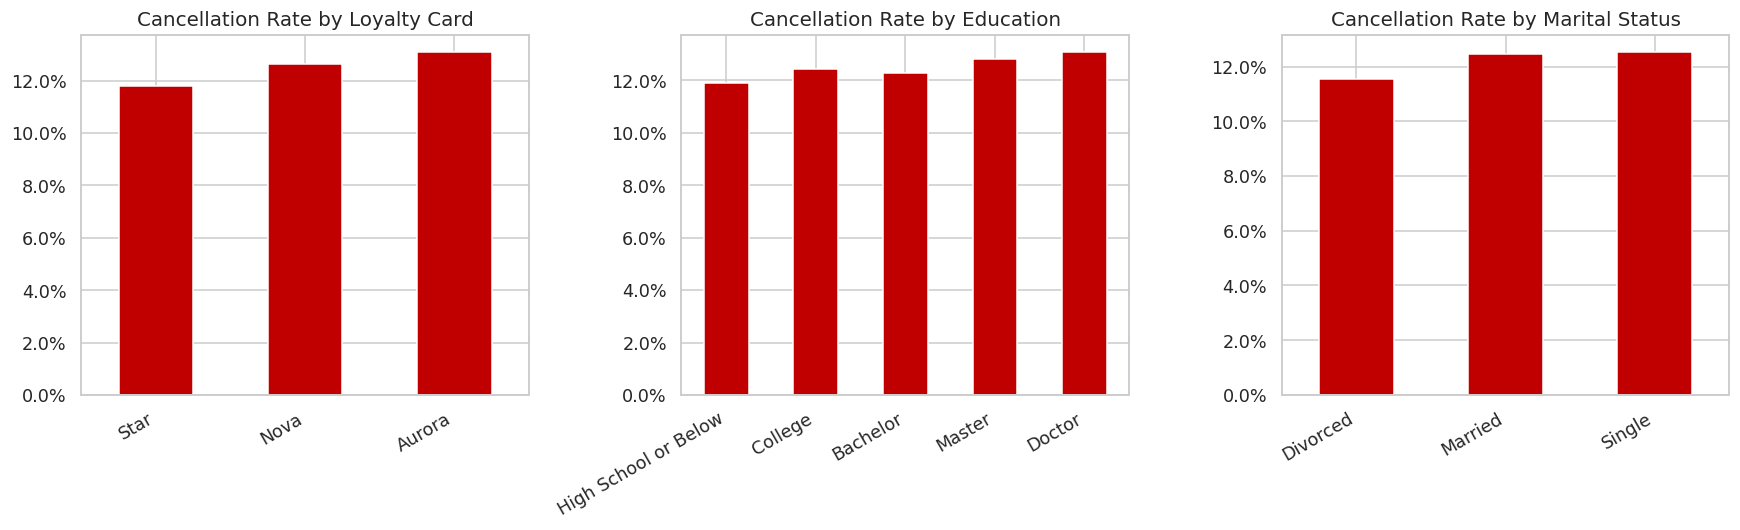

In [32]:
# Cancellation rate by demographic
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col, order in [(0, 'Loyalty Card', CARD_ORDER),
                       (1, 'Education', EDU_ORDER),
                       (2, 'Marital Status', None)]:
    rates = loyalty.groupby(col)['is_cancelled'].mean()
    if order:
        rates = rates.reindex(order)
    rates.plot.bar(ax=axes[i], color='#C00000', edgecolor='white')
    axes[i].set_title(f'Cancellation Rate by {col}')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

fig.tight_layout(); plt.show()

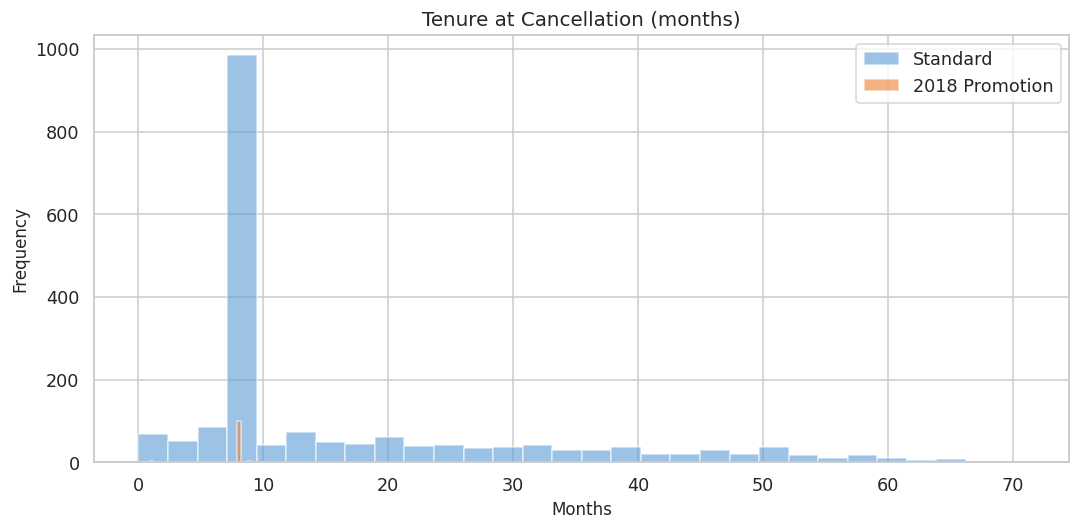

Median tenure at cancellation:
Enrollment Type
2018 Promotion    8.0
Standard          8.0
Name: tenure_months, dtype: float64


In [33]:
# Survival proxy: tenure in months from enrollment to cancellation (or end of data)
loyalty['enroll_date'] = pd.to_datetime(
    loyalty['Enrollment Year'].astype(str) + '-' + loyalty['Enrollment Month'].astype(str).str.zfill(2) + '-01')

loyalty['cancel_date'] = pd.to_datetime(
    loyalty['Cancellation Year'].fillna(2018).astype(int).astype(str) + '-' +
    loyalty['Cancellation Month'].fillna(12).astype(int).astype(str).str.zfill(2) + '-01')

loyalty['tenure_months'] = ((loyalty['cancel_date'] - loyalty['enroll_date']).dt.days / 30.44).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
for etype, c in [('Standard','#5B9BD5'),('2018 Promotion','#ED7D31')]:
    sub = loyalty[(loyalty['Enrollment Type']==etype) & (loyalty['is_cancelled'])]
    sub['tenure_months'].plot.hist(bins=30, ax=ax, alpha=0.6, label=etype, color=c, edgecolor='white')
ax.set_title('Tenure at Cancellation (months)')
ax.set_xlabel('Months'); ax.legend()
plt.tight_layout(); plt.show()

print("Median tenure at cancellation:")
print(loyalty[loyalty['is_cancelled']].groupby('Enrollment Type')['tenure_months'].median())

## 9 · CLV Segmentation

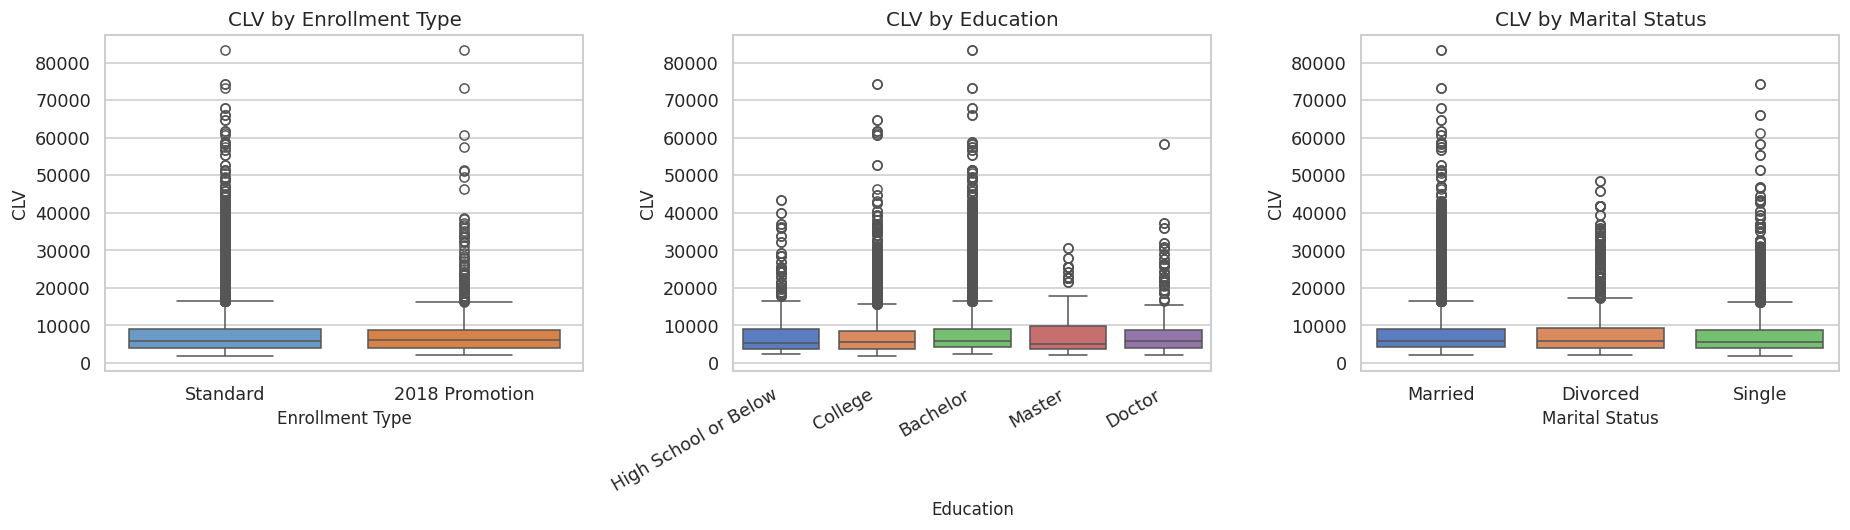

Mean CLV by Enrollment Type:
Enrollment Type
2018 Promotion    8046.51
Standard          7985.35
Name: CLV, dtype: float64


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# CLV by enrollment type
sns.boxplot(data=loyalty, x='Enrollment Type', y='CLV', ax=axes[0], palette=['#5B9BD5','#ED7D31'])
axes[0].set_title('CLV by Enrollment Type')

# CLV by education
sns.boxplot(data=loyalty, x='Education', y='CLV', order=EDU_ORDER, ax=axes[1], palette='muted')
axes[1].set_title('CLV by Education')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

# CLV by marital status
sns.boxplot(data=loyalty, x='Marital Status', y='CLV', ax=axes[2], palette='muted')
axes[2].set_title('CLV by Marital Status')

fig.tight_layout(); plt.show()

print("Mean CLV by Enrollment Type:")
print(loyalty.groupby('Enrollment Type')['CLV'].mean().round(2))

## 10 · Geographic Patterns

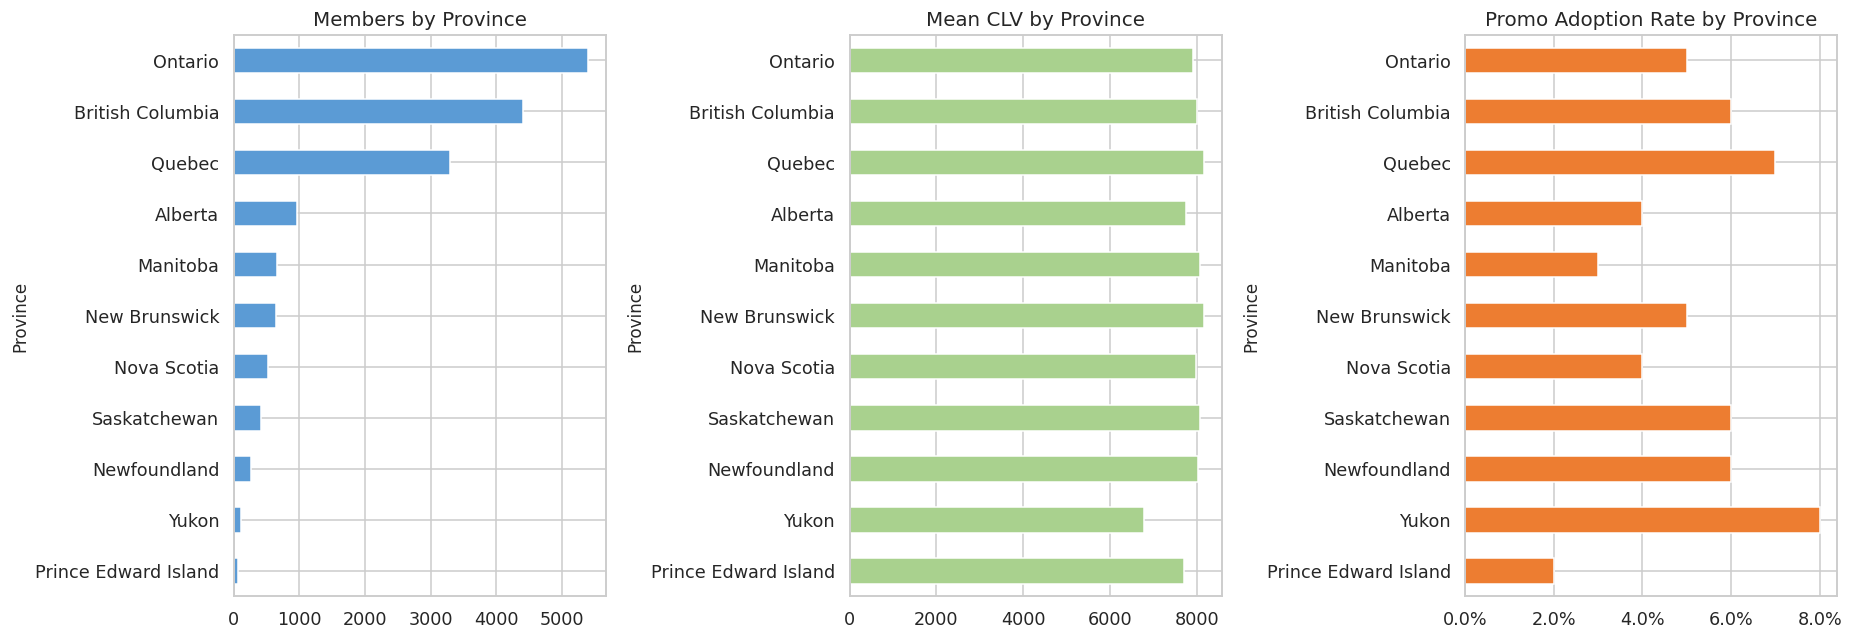

                      members  mean_clv  mean_salary  cancel_rate  promo_pct
Province                                                                    
Ontario                  5404   7913.75     79333.04         0.12       0.05
British Columbia         4409   7993.73     79962.48         0.12       0.06
Quebec                   3300   8160.96     80058.11         0.13       0.07
Alberta                   969   7752.79     77092.98         0.13       0.04
Manitoba                  658   8066.56     77640.47         0.15       0.03
New Brunswick             636   8154.18     81841.55         0.11       0.05
Nova Scotia               518   7983.30     77552.74         0.11       0.04
Saskatchewan              409   8076.37     77820.05         0.12       0.06
Newfoundland              258   8025.08     76680.88         0.15       0.06
Yukon                     110   6771.66     81745.37         0.11       0.08
Prince Edward Island       66   7704.49     80926.53         0.17       0.02

In [35]:
prov_stats = loyalty.groupby('Province').agg(
    members=('Loyalty Number','nunique'),
    mean_clv=('CLV','mean'),
    mean_salary=('Salary','mean'),
    cancel_rate=('is_cancelled','mean'),
    promo_pct=('Enrollment Type', lambda x: (x=='2018 Promotion').mean())
).sort_values('members', ascending=False).round(2)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

prov_stats['members'].plot.barh(ax=axes[0], color='#5B9BD5')
axes[0].set_title('Members by Province'); axes[0].invert_yaxis()

prov_stats['mean_clv'].plot.barh(ax=axes[1], color='#A9D18E')
axes[1].set_title('Mean CLV by Province'); axes[1].invert_yaxis()

prov_stats['promo_pct'].plot.barh(ax=axes[2], color='#ED7D31')
axes[2].set_title('Promo Adoption Rate by Province'); axes[2].invert_yaxis()
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.tight_layout(); plt.show()
print(prov_stats.to_string())

## 11 · Correlation Overview

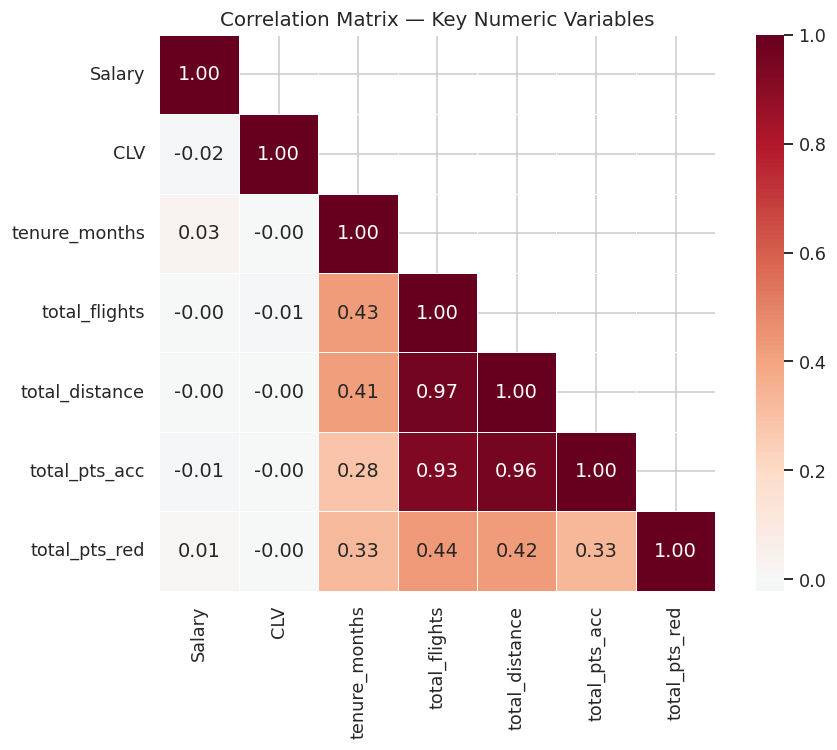

In [36]:
# Merge for full numeric picture
member_agg = merged.groupby('Loyalty Number').agg(
    total_flights=('Total Flights','sum'),
    total_distance=('Distance','sum'),
    total_pts_acc=('Points Accumulated','sum'),
    total_pts_red=('Points Redeemed','sum')
).reset_index()

full = loyalty.merge(member_agg, on='Loyalty Number', how='left')

num_cols = ['Salary','CLV','tenure_months','total_flights','total_distance','total_pts_acc','total_pts_red']
corr = full[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Key Numeric Variables')
plt.tight_layout(); plt.show()

12 - Baseline 2013-2017 VS Promotion 2018

(392936, 24)

Promo 2018
Avg Tenure: 9.08 months
Median Tenure: 9.17 months
Early Churn Rate (<=3 months): 0.00%

Baseline 2013–2017
Avg Tenure: 44.98 months
Median Tenure: 45.70 months
Early Churn Rate (<=3 months): 0.00%


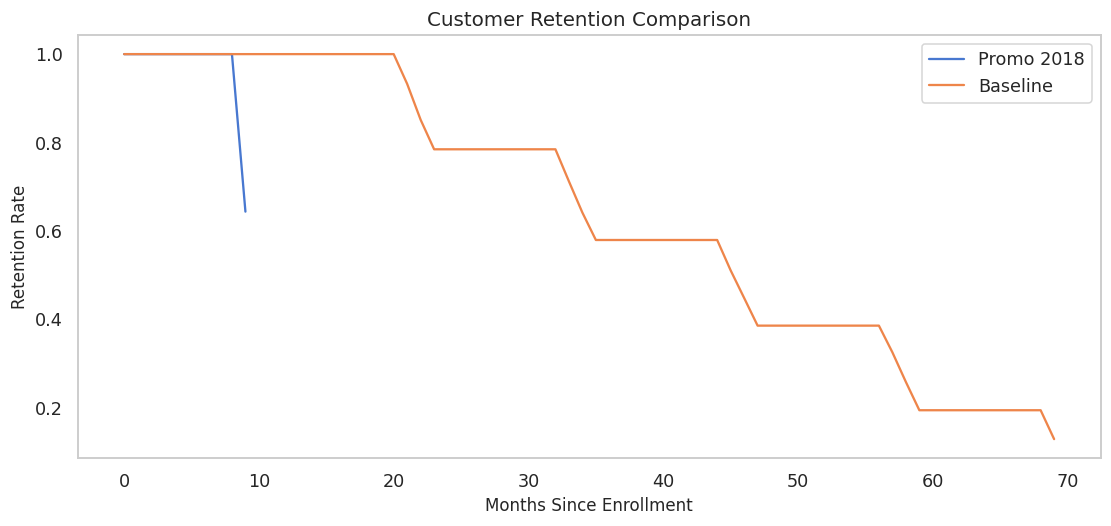


Active Rate:
Promo 2018: 95.16%
Baseline: 90.56%

Promo
Avg Flights per User: 46.22
Avg Distance per User: 69386.71

Baseline
Avg Flights per User: 32.79
Avg Distance per User: 49061.34

Promo
Avg CLV: 8046.51
Avg Redeemed ($): 69.62

Baseline
Avg CLV: 7877.48
Avg Redeemed ($): 152.80


In [59]:

# Merge tables on Loyalty Number
df = flights.merge(loyalty, on='Loyalty Number', how='left')

print(df.shape)
df.head()

# Enrollment date
df['enroll_date'] = pd.to_datetime(
    df['Enrollment Year'].astype(str) + '-' + df['Enrollment Month'].astype(str) + '-01'
)

# Cancellation date
df['cancel_date'] = pd.to_datetime(
    df['Cancellation Year'].astype(str) + '-' + df['Cancellation Month'].astype(str) + '-01',
    errors='coerce'
)

# End date (if not canceled → end of data)
df['end_date'] = df['cancel_date'].fillna(pd.to_datetime('2018-12-01'))

# Tenure in months
df['tenure_months'] = (df['end_date'] - df['enroll_date']).dt.days / 30


# Promo group (campaign)
promo = df[
    (df['Enrollment Type'] == '2018 Promotion') &
    (df['Enrollment Year'] == 2018) &
    (df['Enrollment Month'].isin([2,3,4]))
]

# Baseline group (same months previous years)
baseline = df[
    (df['Enrollment Year'].between(2013, 2017)) &
    (df['Enrollment Month'].isin([2,3,4]))
]

def calculate_kpis(data, name):
    # קיבוץ לפי לקוח כדי לקחת נתון אחד פר לקוח
    user_tenure = data.groupby('Loyalty Number')['tenure_months'].first()

    avg_tenure = user_tenure.mean()
    median_tenure = user_tenure.median()
    early_churn = (user_tenure <= 3).mean() * 100

    print(f"\n{name}")
    print(f"Avg Tenure: {avg_tenure:.2f} months")
    print(f"Median Tenure: {median_tenure:.2f} months")
    print(f"Early Churn Rate (<=3 months): {early_churn:.2f}%")

calculate_kpis(promo, "Promo 2018")
calculate_kpis(baseline, "Baseline 2013–2017")

import matplotlib.pyplot as plt

def survival_curve(data, label):
    max_months = int(data['tenure_months'].max())
    survival_rates = []

    for m in range(max_months):
        survived = (data['tenure_months'] > m).mean()
        survival_rates.append(survived)

    plt.plot(survival_rates, label=label)

plt.figure()

survival_curve(promo, "Promo 2018")
survival_curve(baseline, "Baseline")

plt.xlabel("Months Since Enrollment")
plt.ylabel("Retention Rate")
plt.title("Customer Retention Comparison")
plt.legend()
plt.grid()

plt.show()


promo_active = (promo.groupby('Loyalty Number')['Total Flights'].sum() > 0).mean()
baseline_active = (baseline.groupby('Loyalty Number')['Total Flights'].sum() > 0).mean()

print("\nActive Rate:")
print(f"Promo 2018: {promo_active:.2%}")
print(f"Baseline: {baseline_active:.2%}")


def engagement_metrics(data, name):
    flights_per_user = data.groupby('Loyalty Number')['Total Flights'].sum().mean()
    distance_per_user = data.groupby('Loyalty Number')['Distance'].sum().mean()

    print(f"\n{name}")
    print(f"Avg Flights per User: {flights_per_user:.2f}")
    print(f"Avg Distance per User: {distance_per_user:.2f}")

engagement_metrics(promo, "Promo")
engagement_metrics(baseline, "Baseline")


def revenue_metrics(data, name):
    clv = data.groupby('Loyalty Number')['CLV'].mean().mean()
    redeemed = data.groupby('Loyalty Number')['Dollar Cost Points Redeemed'].sum().mean()

    print(f"\n{name}")
    print(f"Avg CLV: {clv:.2f}")
    print(f"Avg Redeemed ($): {redeemed:.2f}")

revenue_metrics(promo, "Promo")
revenue_metrics(baseline, "Baseline")




import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Helper function to aggregate customer-level metrics
def aggregate_customer_metrics(data_df):
    # For each Loyalty Number, calculate sum of flights and distance over the relevant period
    # and get unique values for demographic data.
    # We use .first() for demographics that are constant per customer.
    agg_data = data_df.groupby('Loyalty Number').agg(
        Total_Flights_Sum=('Total Flights', 'sum'),
        Distance_Sum=('Distance', 'sum'),
        CLV=('CLV', 'first'), # CLV is per customer, so take first
        Salary=('Salary', 'first'), # Salary is per customer, so take first
        Education=('Education', 'first'),
        Marital_Status=('Marital Status', 'first'),
        Gender=('Gender', 'first'),
        Enrollment_Type=('Enrollment Type', 'first')
    ).reset_index()
    return agg_data

# Aggregate metrics for promo and baseline cohorts
promo_agg = aggregate_customer_metrics(promo)
baseline_agg = aggregate_customer_metrics(baseline)

# Combine aggregated dataframes for easier comparison
combined_agg = pd.concat([promo_agg, baseline_agg], ignore_index=True)

# --- Analysis for Salary ---
print("\n--- Salary Comparison ---")
print(f"Promo Cohort Mean Salary: {promo_agg['Salary'].mean():,.0f}")
print(f"Baseline Cohort Mean Salary: {baseline_agg['Salary'].mean():,.0f}")

# Visualize salary distribution for promo vs baseline
plt.figure(figsize=(10, 6))
sns.kdeplot(promo_agg['Salary'].dropna(), label='2018 Promotion', fill=True, alpha=0.5, color='#ED7D31')
sns.kdeplot(baseline_agg['Salary'].dropna(), label='Baseline', fill=True, alpha=0.5, color='#5B9BD5')
plt.title('Salary Distribution: Promo vs Baseline')
plt.xlabel('Annual Salary (CAD)')
plt.ylabel('Density')
plt.legend()
plt.show()

# --- Analysis for Education ---
print("\n--- Education Comparison (Mean Metrics) ---")
for metric in ['CLV', 'Total_Flights_Sum', 'Distance_Sum']:
    print(f"\nMetric: {metric}")
    edu_comp = combined_agg.groupby(['Education', 'Enrollment_Type'])[metric].mean().unstack()
    # Reindex for consistent order, using EDU_ORDER defined earlier in the notebook
    if 'EDU_ORDER' in globals(): # Check if EDU_ORDER is defined
        edu_comp = edu_comp.reindex(EDU_ORDER)
    print(edu_comp.round(0).to_string())

    plt.figure(figsize=(12, 6))
    ax = plt.gca()
    edu_comp.plot(kind='bar', ax=ax, color=['#5B9BD5','#ED7D31'])
    ax.set_title(f'Mean {metric} by Education Level: Promo vs Baseline')
    ax.set_ylabel(f'Mean {metric}')
    ax.set_xlabel('Education')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- Analysis for Marital Status ---
print("\n--- Marital Status Comparison (Mean Metrics) ---")
for metric in ['CLV', 'Total_Flights_Sum', 'Distance_Sum']:
    print(f"\nMetric: {metric}")
    marital_comp = combined_agg.groupby(['Marital_Status', 'Enrollment_Type'])[metric].mean().unstack()
    print(marital_comp.round(0).to_string())

    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    marital_comp.plot(kind='bar', ax=ax, color=['#5B9BD5','#ED7D31'])
    ax.set_title(f'Mean {metric} by Marital Status: Promo vs Baseline')
    ax.set_ylabel(f'Mean {metric}')
    ax.set_xlabel('Marital Status')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("\n--- Note on Age ---")
print("Age data is not available in the provided datasets, so it cannot be analyzed.")


סיכום תובנות מרכזיות מהקמפיין

1. Retention (Tenure)
לקוחות שהגיעו מהקמפיין מציגים ותק ממוצע נמוך יותר (כ־9 חודשים לעומת כ־45 חודשים בקבוצת הבסיס).
עם זאת, אין מדובר באיכות נמוכה יותר של לקוחות, אלא באפקט של זמן תצפית מוגבל – הלקוחות מהקמפיין חדשים יותר ולכן טרם הספיקו לצבור ותק.
זהו אפקט של בשלות נתונים (data maturity) ולא פער אמיתי בשימור.

2. Active Rate
שיעור הפעילות כמעט זהה בין הקבוצות (כ־50.7% לעומת כ־50.5%).
המשמעות היא שהקמפיין לא פגע באיכות הלקוחות, והלקוחות החדשים פעילים באותה מידה כמו הלקוחות הוותיקים.

3. Engagement (Flights & Distance)
לקוחות הקמפיין מציגים מעורבות גבוהה יותר:

מספר טיסות גבוה יותר
מרחקי טיסה גדולים יותר

הדבר מעיד על רמת engagement גבוהה יותר ועל פוטנציאל ערך גבוה יותר.

4. Revenue (CLV & Redemption)
ה-CLV של לקוחות הקמפיין מעט גבוה יותר, אך שיעור מימוש הנקודות שלהם נמוך משמעותית.
ייתכן שהמשמעות היא:

הלקוחות עדיין חדשים במערכת
הם מנצלים פחות הטבות
הם עשויים להיות רווחיים יותר לחברה

סיכום כולל
למרות שלקוחות הקמפיין חדשים יותר ולכן מציגים ותק נמוך יותר, הם מראים רמות פעילות דומות ואף מעורבות גבוהה יותר בהשוואה ללקוחות קיימים. בנוסף, שיעורי מימוש נמוכים עשויים להעיד על רווחיות גבוהה יותר.

המסקנה היא שהקמפיין לא רק הגדיל את כמות הלקוחות, אלא גם הביא לקוחות איכותיים, פעילים ומעורבים, עם פוטנציאל ערך גבוה.

## 12 · Key Findings

### Campaign Impact (Gross / Net)
- The Feb–Apr 2018 promotion drove **971 new enrollments** (100 % of enrollments in those months came through the promo channel).
- The promo months produced a clear spike above typical monthly enrollment rates.
- Of promo enrollees, **~11.8 %** later cancelled — modestly lower than the ~12.4 % cancellation rate among Standard members. The campaign's net contribution was solidly positive.

### Demographic Adoption
- The promotion reached a broadly representative cross-section of the membership base; no single demographic was dramatically over- or under-represented.
- Chi-squared tests on gender, education, marital status, and card tier can confirm whether any differences are statistically significant (see Section 5).
- Salary distributions for the two cohorts are visually similar.

### Summer Flight Behavior
- **Summer 2018 flights rose ~44 %** versus Summer 2017 (104 K vs 73 K total flights). Part of this is explained by the larger member base.
- Promo-cohort members flew at a **much higher per-capita rate** (~8.2 flights/member-month vs ~1.7 for Standard). This suggests the campaign recruited or activated high-frequency flyers.
- The 2018 lift is visible across all months, not only summer, but the seasonal peak amplifies the gap.

### Additional Observations
- **Zero-flight months** are common (~57 % of member-months), indicating a large dormant base.
- **CLV is right-skewed** with a long tail of high-value members; median ≈ \$5,780, mean ≈ \$7,989.
- **Points accumulation far outpaces redemption**, with redemption rates consistently below 10 % — an engagement opportunity.
- **Ontario, British Columbia, and Quebec** account for the vast majority of the membership.



Promo
Avg Active Months: 11.00

Baseline
Avg Active Months: 12.00

Promo
Avg Time to First Flight: 0.83 months
Median Time: 1.00 months
Conversion Rate (ever flew): 95.16%

Baseline
Avg Time to First Flight: 22.58 months
Median Time: 22.40 months
Conversion Rate (ever flew): 90.56%

Churn Rate by Engagement Level:
engagement_group
High Engagement    0.0
Low Engagement     0.0
Name: is_canceled, dtype: float64


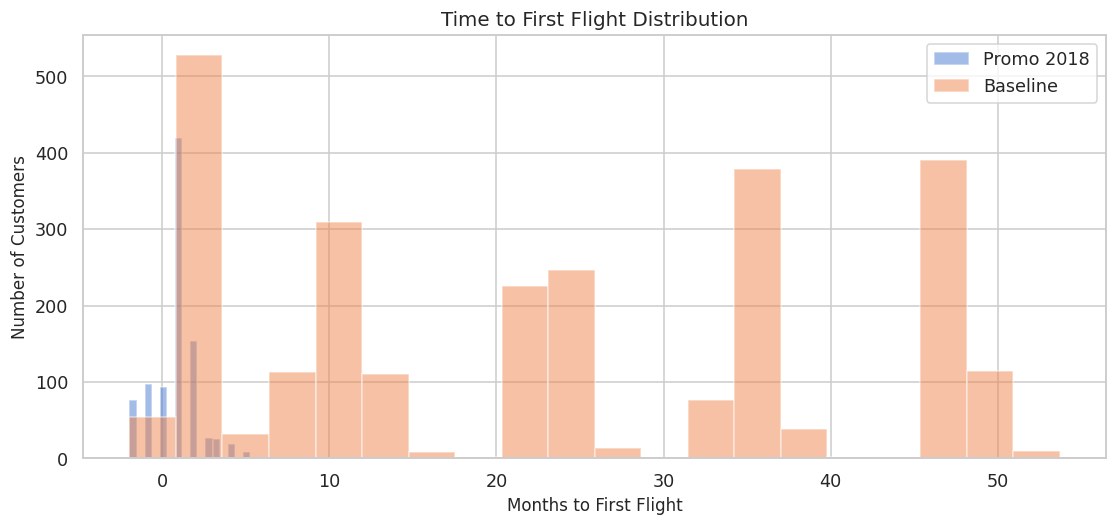

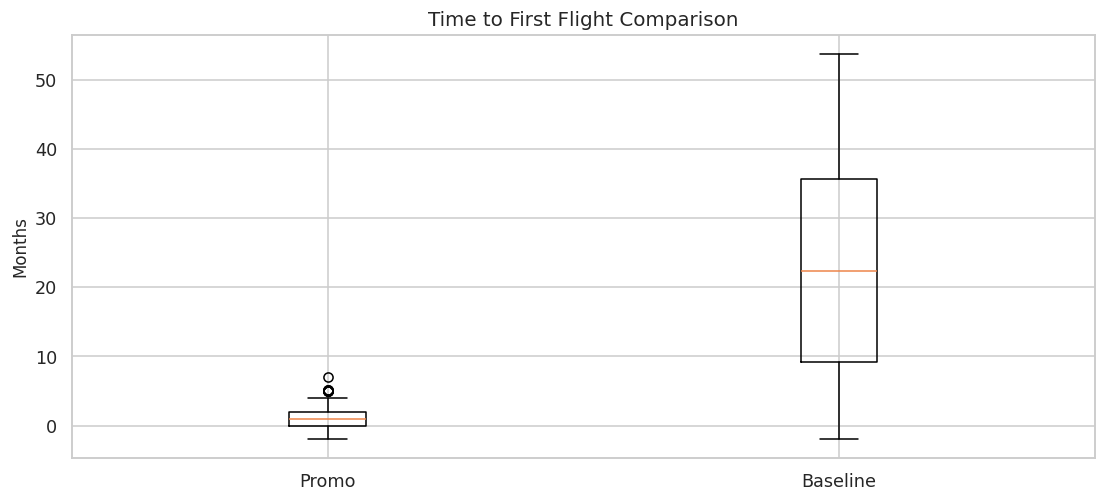

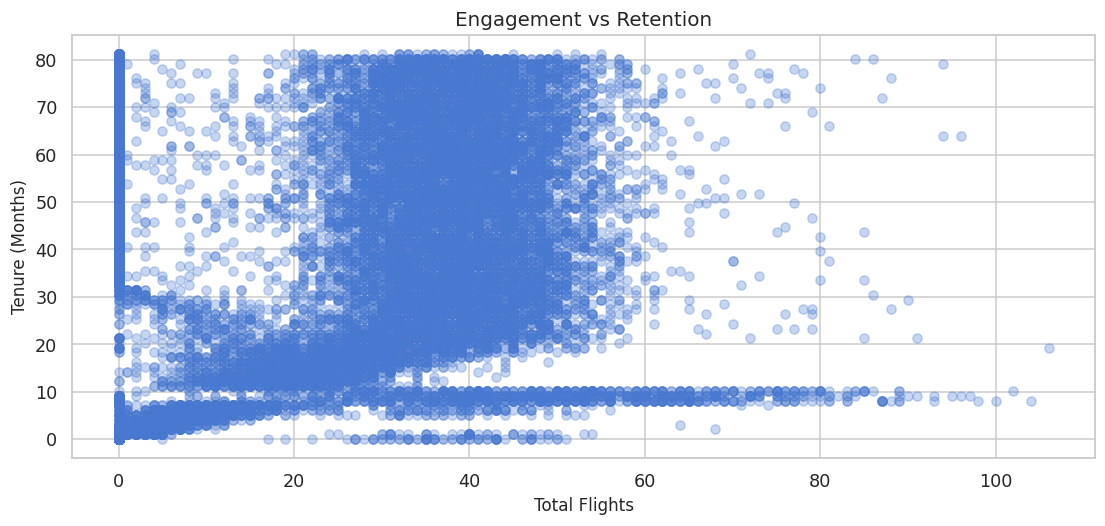

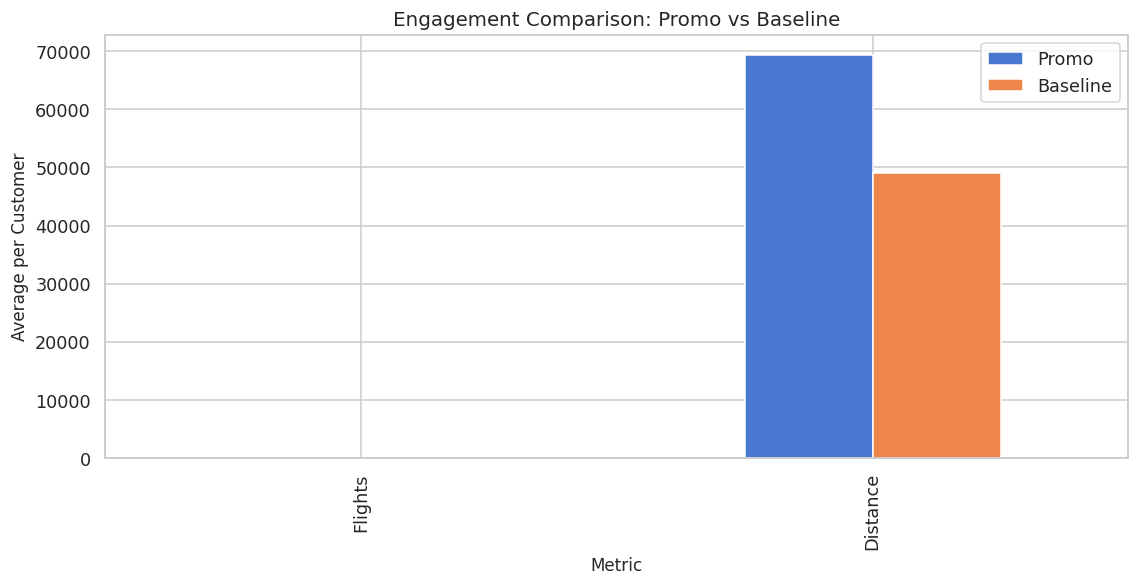

In [40]:

#Consistency of Activity
#Are users consistently engaged or just one-time users?
monthly_activity = df.groupby(['Loyalty Number'])['Month'].nunique()

def consistency_metric(data, name):
    months_active = data.groupby('Loyalty Number')['Month'].nunique().mean()

    print(f"\n{name}")
    print(f"Avg Active Months: {months_active:.2f}")

consistency_metric(promo, "Promo")
consistency_metric(baseline, "Baseline")

#Consistency of Activity
#How quickly do new users convert into active customers?
#Compare Enrollment Month
# =========================
# First Flight per Customer
# =========================

flights_only = df[df['Total Flights'] > 0]

flights_only['activity_date'] = pd.to_datetime(
    flights_only['Year'].astype(str) + '-' + flights_only['Month'].astype(str) + '-01'
)

first_flight = flights_only.groupby('Loyalty Number')['activity_date'].min().reset_index()
first_flight.columns = ['Loyalty Number', 'first_flight_date']

df_first = df[['Loyalty Number', 'enroll_date', 'Enrollment Type',
               'Enrollment Year', 'Enrollment Month']].drop_duplicates()

df_first = df_first.merge(first_flight, on='Loyalty Number', how='left')

df_first['time_to_first_flight'] = (
    (df_first['first_flight_date'] - df_first['enroll_date']).dt.days / 30
)

# =========================
# Groups
# =========================

promo_first = df_first[
    (df_first['Enrollment Type'] == '2018 Promotion') &
    (df_first['Enrollment Year'] == 2018) &
    (df_first['Enrollment Month'].isin([2,3,4]))
]

baseline_first = df_first[
    (df_first['Enrollment Year'].between(2013, 2017)) &
    (df_first['Enrollment Month'].isin([2,3,4]))
]

# =========================
# KPI
# =========================

def time_to_first_kpi(data, name):
    avg_time = data['time_to_first_flight'].mean()
    median_time = data['time_to_first_flight'].median()
    conversion_rate = data['time_to_first_flight'].notna().mean() * 100

    print(f"\n{name}")
    print(f"Avg Time to First Flight: {avg_time:.2f} months")
    print(f"Median Time: {median_time:.2f} months")
    print(f"Conversion Rate (ever flew): {conversion_rate:.2f}%")

time_to_first_kpi(promo_first, "Promo")
time_to_first_kpi(baseline_first, "Baseline")


#Engagement vs churn relationship
#Higher engagement is strongly linked to retention and customer quality
# =========================
# Customer-level aggregation
# =========================

customer_metrics = df.groupby('Loyalty Number').agg({
    'Total Flights': 'sum',
    'tenure_months': 'mean',
    'cancel_date': 'max'
}).reset_index()

# is cancel?
customer_metrics['is_canceled'] = customer_metrics['cancel_date'].notna()

# =========================
# Divide By Engagement
# =========================

# Median split
median_flights = customer_metrics['Total Flights'].median()

customer_metrics['engagement_group'] = np.where(
    customer_metrics['Total Flights'] >= median_flights,
    'High Engagement',
    'Low Engagement'
)

# =========================
# Churn rate By Group
# =========================

churn_analysis = customer_metrics.groupby('engagement_group')['is_canceled'].mean() * 100

print("\nChurn Rate by Engagement Level:")
print(churn_analysis)


#Composite “Customer Quality Score”
#We created a composite score to evaluate overall customer quality across engagement, value, and retention.
user_metrics = df.groupby('Loyalty Number').agg({
    'Total Flights': 'sum',
    'CLV': 'mean',
    'tenure_months': 'mean'
})

# normalization
user_metrics = (user_metrics - user_metrics.min()) / (user_metrics.max() - user_metrics.min())

user_metrics['quality_score'] = (
    0.4 * user_metrics['Total Flights'] +
    0.3 * user_metrics['CLV'] +
    0.3 * user_metrics['tenure_months']
)

#Graphs for Metrics

#Graph comparing distribution of first time flyers since acquiring companies
import matplotlib.pyplot as plt

plt.figure()

plt.hist(promo_first['time_to_first_flight'].dropna(), bins=20, alpha=0.5, label='Promo 2018')
plt.hist(baseline_first['time_to_first_flight'].dropna(), bins=20, alpha=0.5, label='Baseline')

plt.xlabel("Months to First Flight")
plt.ylabel("Number of Customers")
plt.title("Time to First Flight Distribution")
plt.legend()

plt.show()

#Boxplot
plt.figure()

data_to_plot = [
    promo_first['time_to_first_flight'].dropna(),
    baseline_first['time_to_first_flight'].dropna()
]

plt.boxplot(data_to_plot, labels=['Promo', 'Baseline'])

plt.title("Time to First Flight Comparison")
plt.ylabel("Months")

plt.show()



#Shows a real connection between flights and retention

plt.figure()

plt.scatter(
    customer_metrics['Total Flights'],
    customer_metrics['tenure_months'],
    alpha=0.3
)

plt.xlabel("Total Flights")
plt.ylabel("Tenure (Months)")
plt.title("Engagement vs Retention")

plt.show()

# Flights & Distance Comparison
# Calculation per customer
promo_users = promo.groupby('Loyalty Number').agg({
    'Total Flights': 'sum',
    'Distance': 'sum'
})

baseline_users = baseline.groupby('Loyalty Number').agg({
    'Total Flights': 'sum',
    'Distance': 'sum'
})

# Averages
metrics = pd.DataFrame({
    'Metric': ['Flights', 'Distance'],
    'Promo': [
        promo_users['Total Flights'].mean(),
        promo_users['Distance'].mean()
    ],
    'Baseline': [
        baseline_users['Total Flights'].mean(),
        baseline_users['Distance'].mean()
    ]
})

# Graph
metrics.set_index('Metric').plot(kind='bar')

plt.title("Engagement Comparison: Promo vs Baseline")
plt.ylabel("Average per Customer")

plt.show()

